diene: means 4π;
ene: means 2π;
deltaG means deltaGrxn;
deltaGa or Active Energy means Active Free Energy;

# 1 Import

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [2]:
import os, glob, shutil
import pandas as pd
import pickle
import numpy as np
from matplotlib import pyplot as plt
from rdkit import Chem
from hyperopt import hp
from tqdm import tqdm
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
# Tree
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
# Linear 
from sklearn.linear_model import Lasso, Ridge, BayesianRidge, SGDRegressor, LinearRegression
# SVM
from sklearn.svm import SVR
# Nearest Neighbour
from sklearn.neighbors import KNeighborsRegressor

In [4]:
from Code import model_train, gendes

In [5]:
CSV_FILE_DIR= r"Data/DFT_Result"
QM_MAP = "Ignored/all_property_detailSterimol_witharea.pkl" # Copy from smiles_csv
DATA_GA_FILE = CSV_FILE_DIR + "/" + "Active_Energy.csv"
DATA_G_FILE = CSV_FILE_DIR + "/" + "Rxn.csv"
# os.mkdir(CSV_FILE_DIR + "/" + "Descriptors")

# 2 Train Models And 5-Fold Result

## 2.1 Load Data

In [6]:
def get_train_ids(test_ids):
    data_G = pd.read_csv(DATA_G_FILE)
    data_Ga = pd.read_csv(DATA_GA_FILE).iloc[test_ids]
    str_set = set()
    train_ids = set()
    for row_id, row in data_Ga.iterrows():
        str_set.add(f"{row['Diene_Index']:05}_{row['Ene_Index']:05}_{row['Structure_id']:05}")
    for row_id, row in data_G.iterrows():
        if np.isnan(row['Interaction']) or f"{row['Diene_Index']:05}_{row['Ene_Index']:05}_{row['Structure_id']:05}" not in str_set:
            train_ids.add(row_id)
    return list(train_ids)

In [7]:
def generate_max_min(X, indexs_list):
    final_list = []
    for indexs in indexs_list:
        temp = X[:, indexs]
        final_list += [np.max(temp, axis=1), np.min(temp, axis=1)]
    return np.array(final_list).T

In [8]:
data_G = pd.read_csv(DATA_G_FILE)
data_Ga = pd.read_csv(DATA_GA_FILE)
X_G, _ = model_train.read_df(data_G, QM_MAP)
X_Ga, _ = model_train.read_df(data_Ga, QM_MAP)
Y_DD = data_Ga['Diene_Distort'].to_numpy()
Y_ED = data_Ga['Ene_Distort'].to_numpy()
Y_IN = data_Ga['Interaction'].to_numpy()
Y_Ga = data_Ga['deltaGa(Solvent)'].to_numpy()
Y_G = data_Ga['deltaG']
Y_G_data_G = data_G['deltaG']

100%|██████████| 8273/8273 [00:01<00:00, 5481.81it/s]


## 2.2 Draw Figures 

### 2.2.1 Descriptors Correlation(used in SI)

0.9100133038161794


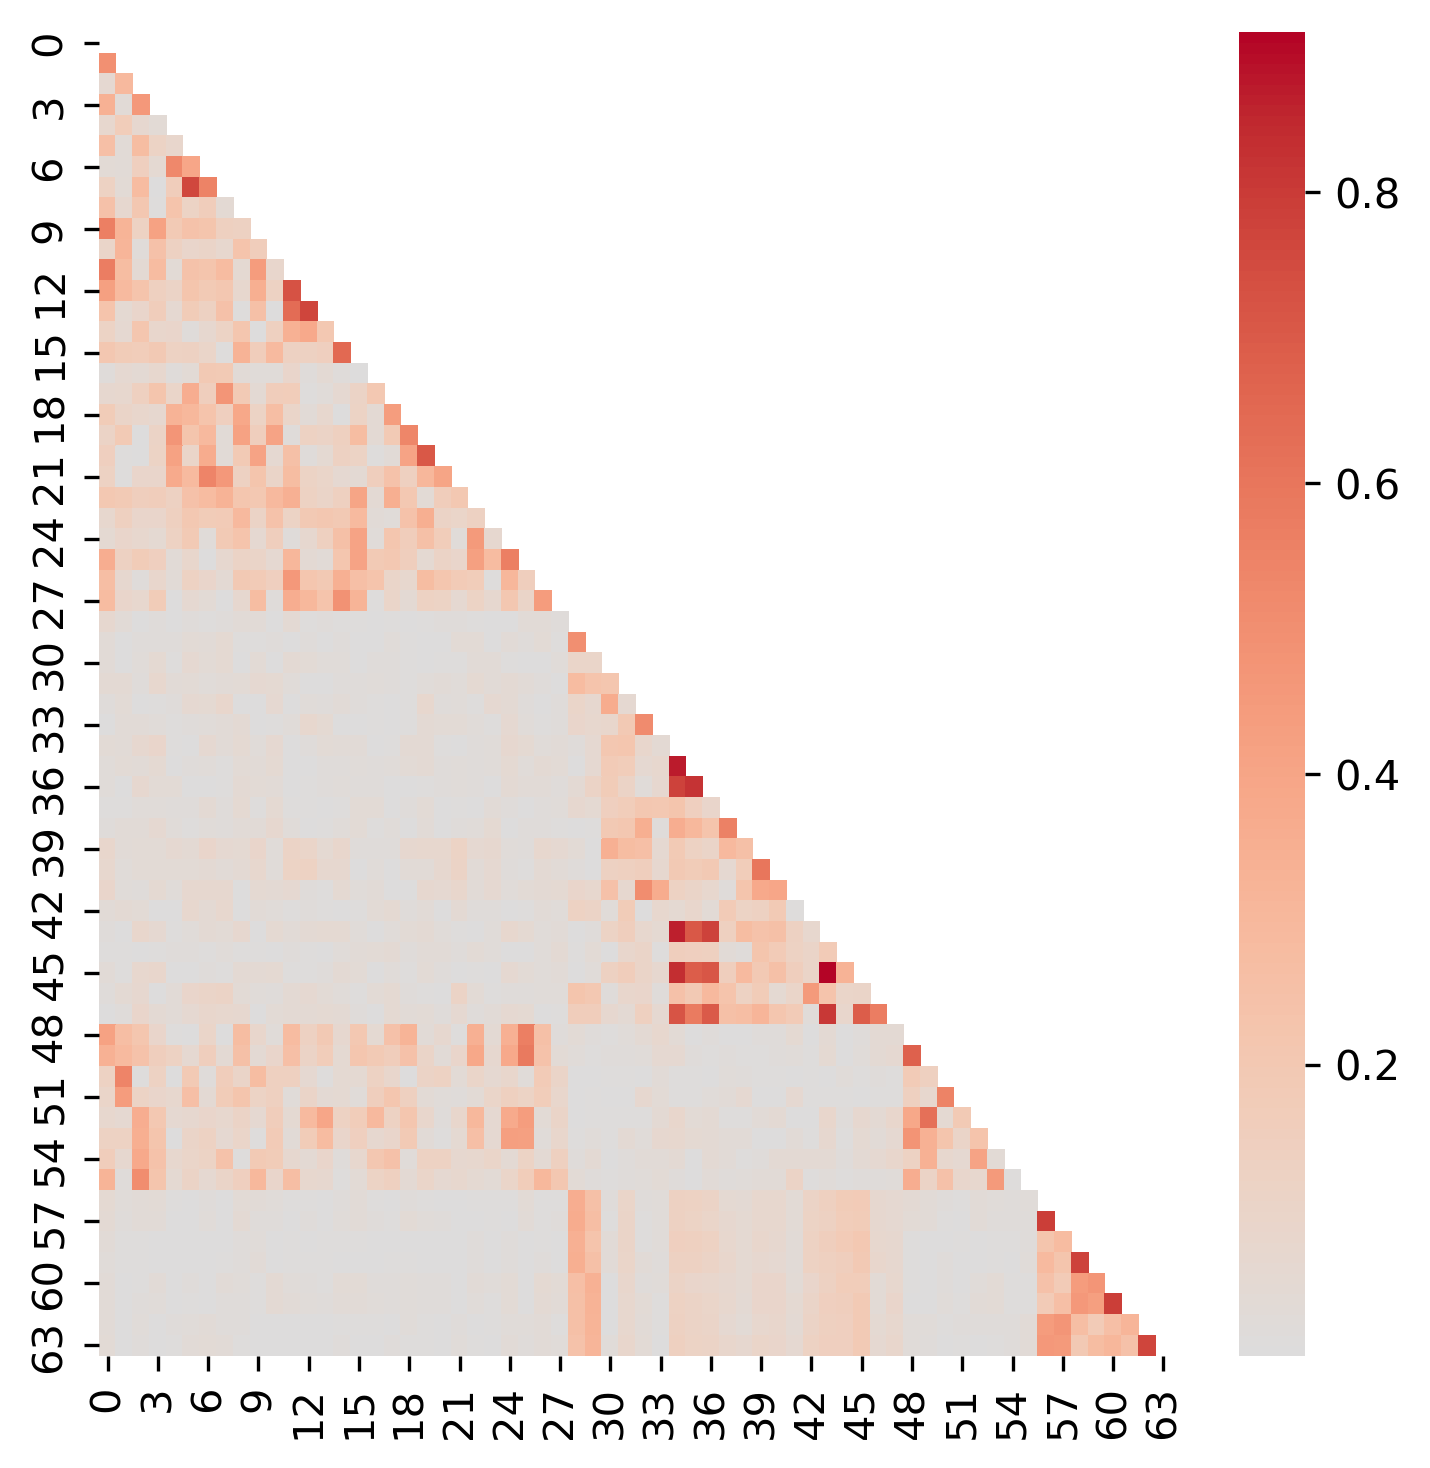

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

model_train.draw_correlation_map(X_Ga, save_name='Figure/Figure_SN_Descriptors_Correlation', useSVG=1, figure_size=(5,5), annot=False, show_label=True)

### 2.2.2 Energies Distribution (Figure 3 in paper)

34.39125286906506


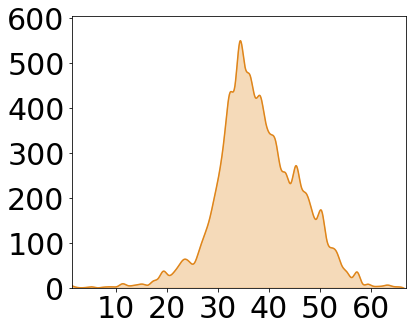

In [12]:
model_train.calc_distribution_line([Y_Ga], eachsize=1, ylab=None, return_result = False, colors=['#df851a'], save_name='Figure/Figure_3_FreeEnergies_Distribution', useSVG=1, figure_size=(6,5))
# Y_G, '#7d9263'

21.015415108468467
13.150113480870871
-14.838102700450449


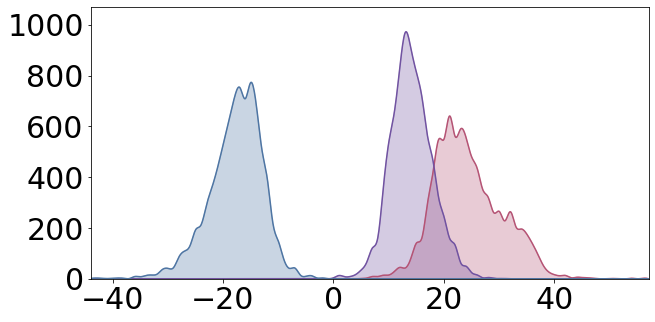

In [13]:
model_train.calc_distribution_line([Y_DD, Y_ED, -1 * Y_IN], eachsize=1, ylab=None, return_result = False, colors=['#b55475', '#7153a1', '#4e75a3'], save_name='Figure/Figure_3_DIEnergies_Distribution', useSVG=1, figure_size=(10,5))

In [ ]:
model_train.calc_distribution_line([Y_Ga, Y_G, Y_DD, Y_ED, -1 * Y_IN], eachsize=1, ylab=None, return_result = False, colors=['#df851a', '#7d9263', '#b55475', '#7153a1', '#4e75a3'], save_name='Figure/Figure_3_Energies_Distribution', useSVG=1, figure_size=(12,5))

In [17]:
np.triu(np.ones_like(correlation_matrix, dtype=bool))

array([[ True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True],
       [False, False,  True,  True,  True],
       [False, False, False,  True,  True],
       [False, False, False, False,  True]])

1.0


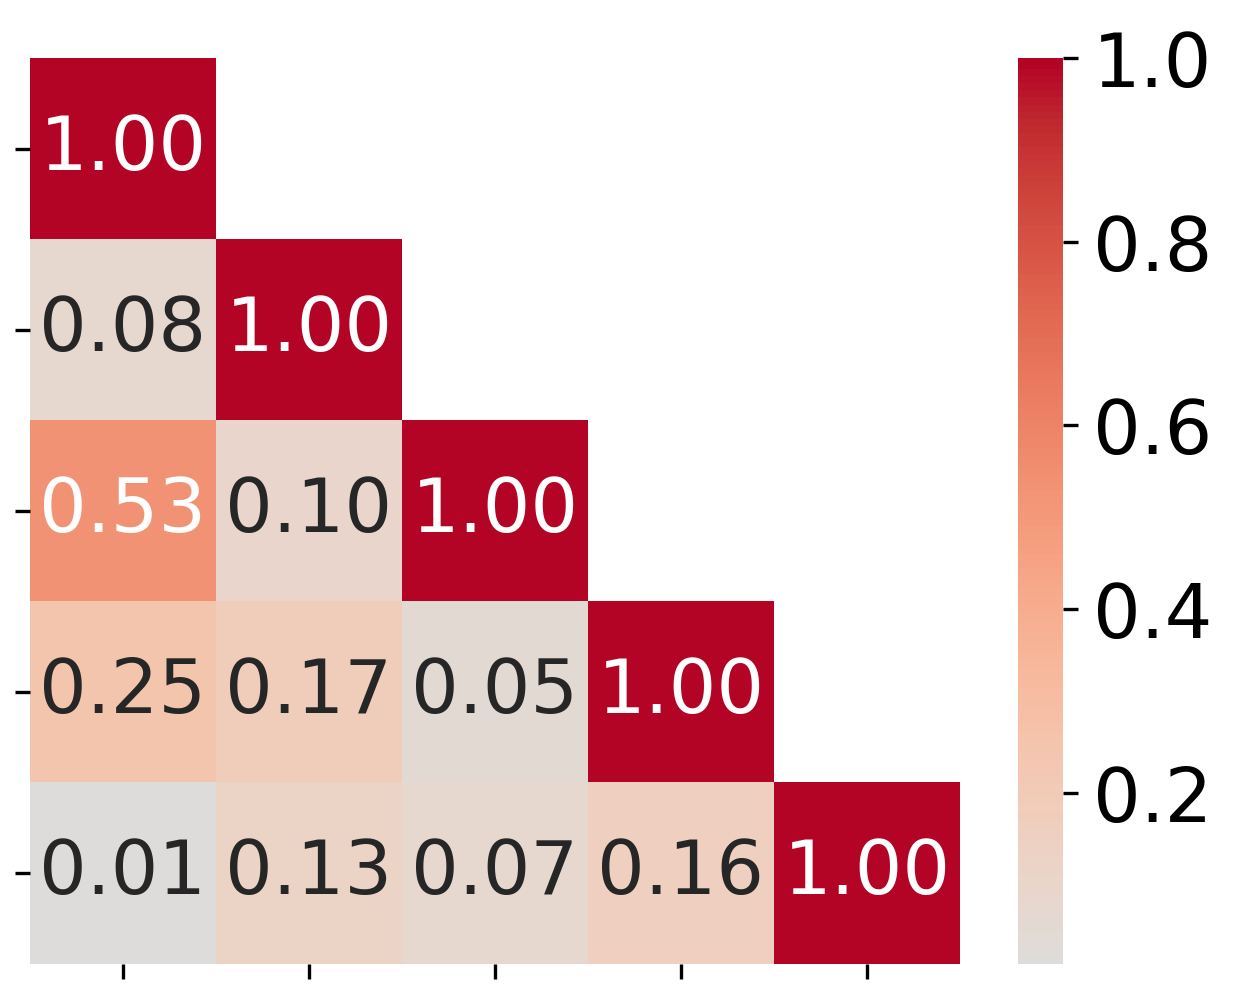

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = np.array([Y_Ga, Y_G, Y_DD, Y_ED, -1 * Y_IN]).T
# model_train.draw_correlation_map(data, save_name='Figure/Figure_4_Energies_Correlation', useSVG=1, figure_size=(5,5))
df = pd.DataFrame(data)
# correlation_matrix = np.abs(df.corr())

n = len(df.columns)
correlation_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            # 对角线设为1
            correlation_matrix[i, j] = 1.0
        else:
            # 用列j预测列i
            X = df.iloc[:, j].values.reshape(-1, 1)
            y = df.iloc[:, i].values
            model = LinearRegression()
            model.fit(X, y)
            correlation_matrix[i, j] = model.score(X, y)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
print(np.max(correlation_matrix[~mask]))
f, ax = plt.subplots(figsize=(5, 4), dpi=300)
annot_kws = {"fontsize": 18}
ax = sns.heatmap(correlation_matrix, 
        mask=mask,
        cmap='coolwarm',    
        annot=True,         
        fmt='.2f',          
        center=0,           
        cbar=1,
        annot_kws=annot_kws,)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
# if not show_label:
ax.set_xticklabels([])
ax.set_yticklabels([])
# plt.tight_layout()
# if useSVG:
#     plt.savefig(f"{save_name}.svg", format="svg", bbox_inches='tight')
# else:
plt.savefig("Figure/Figure_3_Correlation.png", dpi=300, bbox_inches='tight')

0.3767221312325091


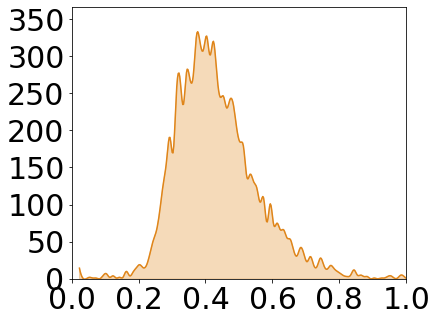

In [22]:
model_train.calc_distribution_line([Y_IN / (Y_DD + Y_ED)], eachsize=0.01, ylab=None, return_result = False, colors=['#df851a', '#7d9263', '#b55475', '#7153a1', '#4e75a3'], save_name='Figure/4pd_alld', useSVG=1, figure_size=(6,5), xlimit=[0,1])

## 2.3 Model Performance

In [10]:
# Full Model(PhysOrg + SVO + deltaG)
from sklearn.model_selection import KFold, cross_val_score
k = KFold(n_splits=5, shuffle=True, random_state=0).split(X_Ga)
k = [[a,b, get_train_ids(b)] for a,b in k]

all_y_preds = []
all_y_trues = []
for train_ids, test_ids, train_ids_G in k:
    all_y_pred = []
    all_y_true = []
    Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
    Gmodel.fit(X_G[train_ids_G], Y_G_data_G[train_ids_G])
    predG = Gmodel.predict(X_Ga)
    X_removed = np.hstack([X_Ga, predG.reshape(-1, 1)])
    for y_id, Y_target in enumerate([Y_DD, Y_ED, Y_IN, Y_Ga]):
        X_train = X_removed[train_ids]
        X_test = X_removed[test_ids]
        # X_train, mean, std = model_train.normalize_axis(X_removed[train_ids])
        # X_test, _, _ = model_train.normalize_axis(X_removed[test_ids], 0, mean=mean, std=std)
        model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
        model.fit(X_train, Y_target[train_ids])
        y_pred = model.predict(X_test)
        all_y_pred.append(y_pred)
        all_y_true.append(Y_target[test_ids])
        print(model_train.r2_score(Y_target[test_ids], y_pred))
    all_y_preds.append(all_y_pred)
    all_y_trues.append(all_y_true)

r2_score, mae, mse = [[] for _ in range(4)], [[] for _ in range(4)], [[] for _ in range(4)]
for [all_y_pred, all_y_true] in zip(all_y_preds, all_y_trues):
    y_dd_pred, y_ed_pred, y_in_pred, y_g_pred = all_y_pred
    y_dd_true, y_ed_true, y_in_true, y_g_true = all_y_true
    for y_id, [y_true, y_pred] in enumerate(zip([y_dd_true, y_ed_true, y_in_true, y_g_true], 
                                                [y_dd_pred, y_ed_pred, y_in_pred, y_g_pred])):
        r2_score[y_id].append(model_train.r2_score(y_true, y_pred))
        mae[y_id].append(model_train.mean_absolute_error(y_true, y_pred))
        mse[y_id].append(model_train.mean_squared_error(y_true, y_pred))
rmse = np.sqrt(mse)
print(["4π Distortion", "2π Distortion", "Interaction", "Active Energy"])
print(np.array(r2_score).mean(axis=1))
print(np.array(mae).mean(axis=1))
print(np.array(mse).mean(axis=1))
print(np.array(rmse).mean(axis=1))

0.9370320657715646
0.8227931288926027
0.7992784540715065
0.9266434877962927
0.9358298877048404
0.8234806690973437
0.7739276015372567
0.9226917315959509
0.9390875420913546
0.8262269069455586
0.7878753257874859
0.9249778352815207
0.9379671463427015
0.8298701107613583
0.78068016345881
0.9265361824316221
0.9361903470110515
0.8154145560150922
0.7898266252757122
0.9131061512216511
['4π Distortion', '2π Distortion', 'Interaction', 'Active Energy']
[0.9372214  0.82355707 0.78631763 0.92279108]
[1.08658727 1.15255578 1.56234679 1.58751902]
[2.34027415 2.5539158  4.96364815 4.73316775]
[1.52966974 1.5974534  2.22776674 2.17436764]


In [23]:
DD_Pred = np.zeros_like(Y_DD)
ED_Pred = np.zeros_like(Y_ED)
IN_Pred = np.zeros_like(Y_IN)
G_Pred = np.zeros_like(Y_Ga)
for k_id, (train_ids, test_ids, train_ids_G) in enumerate(k):
    DD_Pred[test_ids] = all_y_preds[k_id][0]
    ED_Pred[test_ids] = all_y_preds[k_id][1]
    IN_Pred[test_ids] = all_y_preds[k_id][2]
    G_Pred[test_ids] = all_y_preds[k_id][3]

### Graph

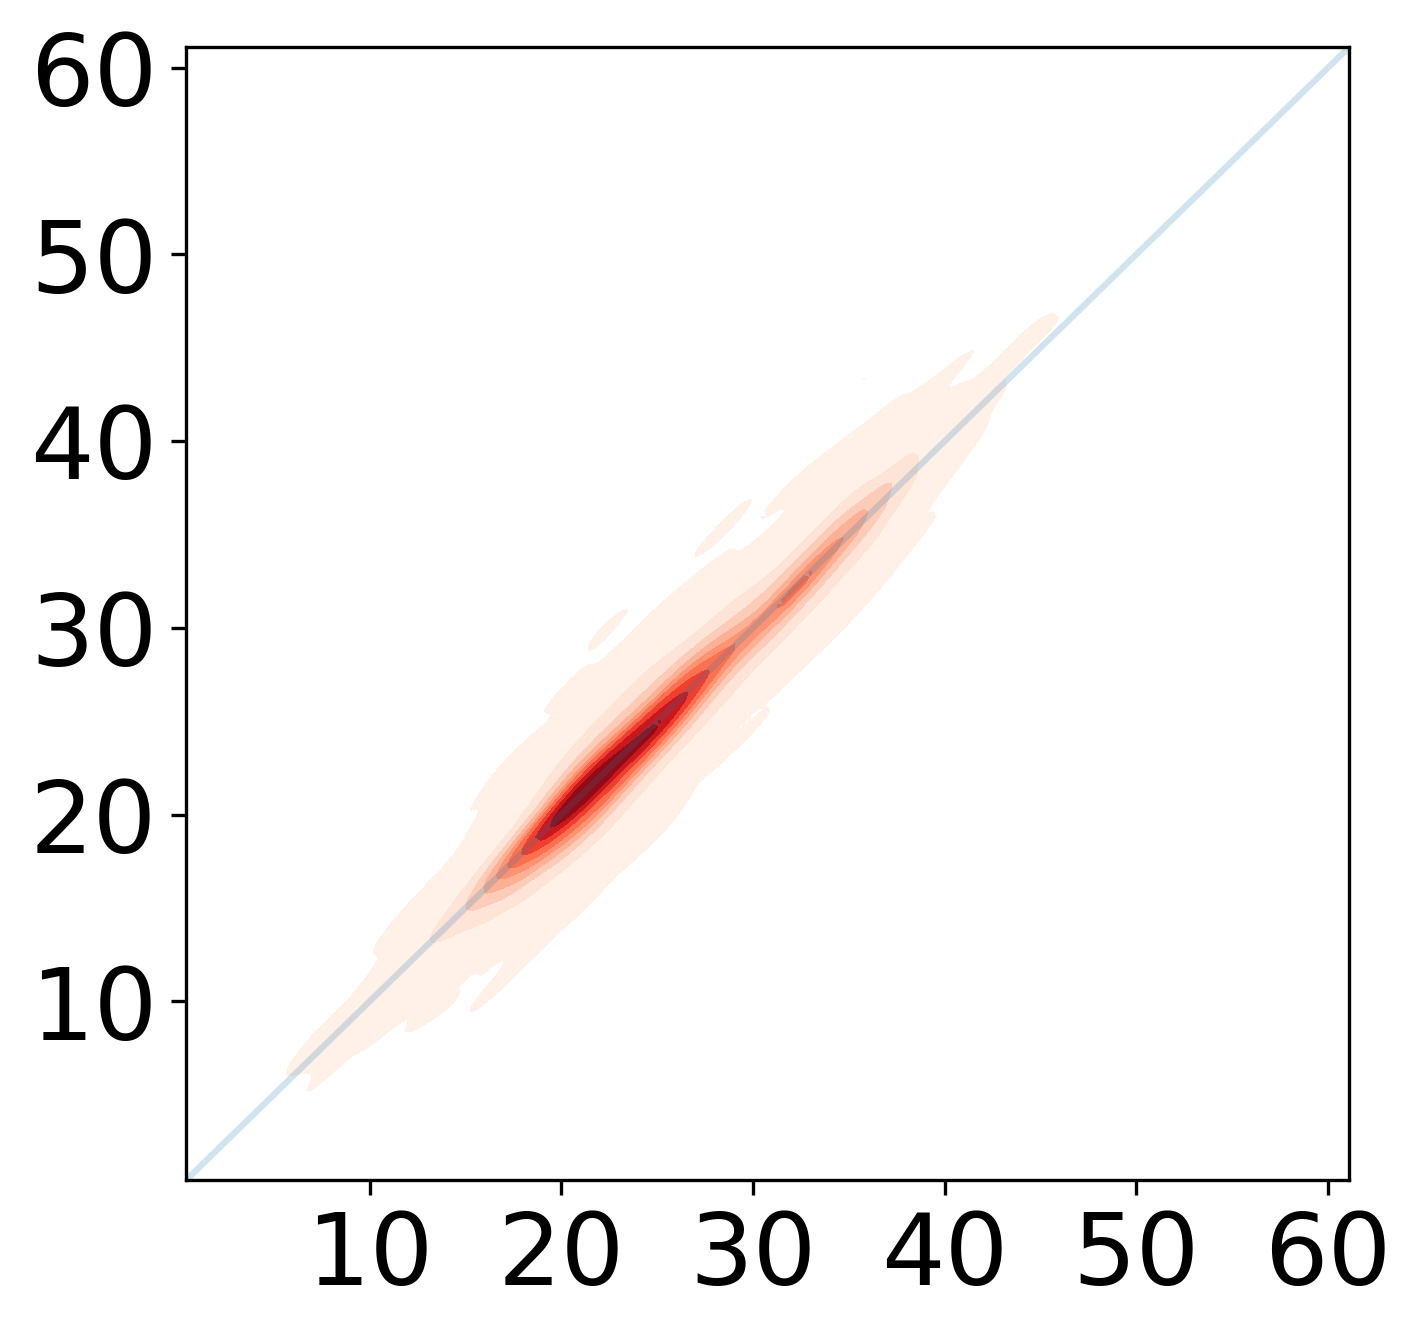

In [28]:
# 4π Distortion
model_train.plot_scatter_with_metrics(DD_Pred, Y_DD, alpha=0.01)

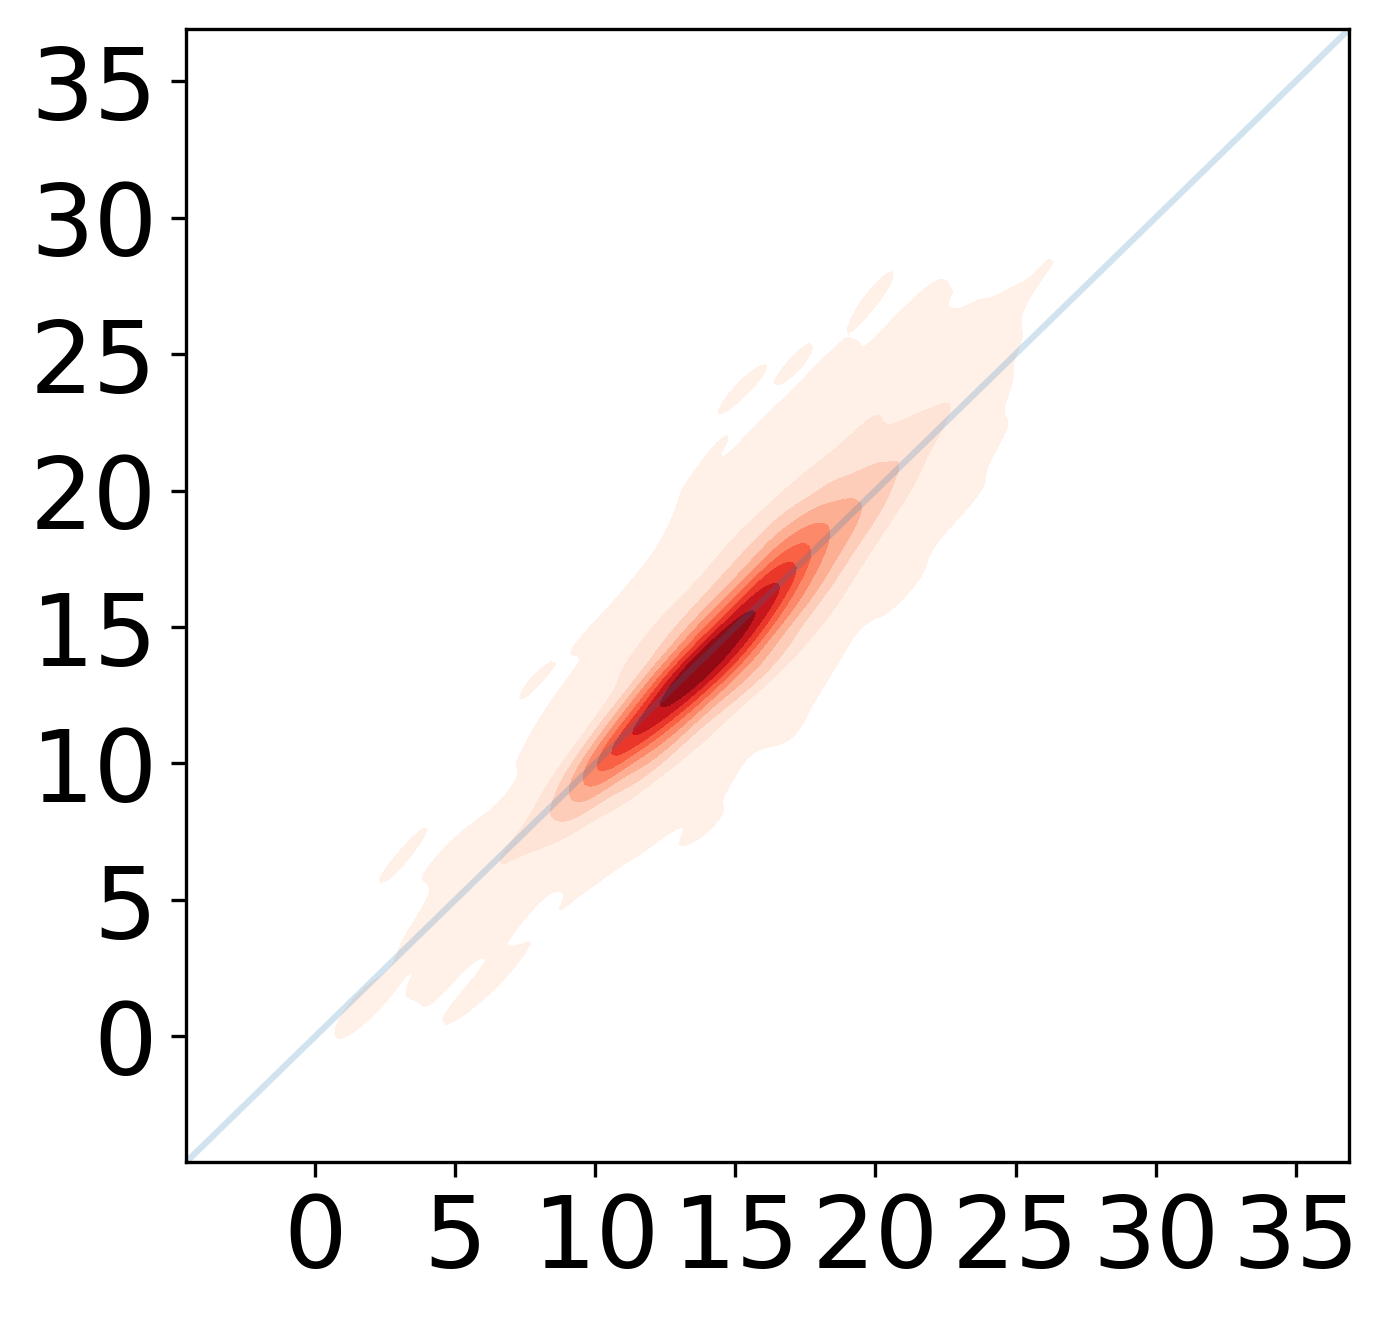

In [29]:
# 2π Distortion
model_train.plot_scatter_with_metrics(ED_Pred, Y_ED, alpha=0.01)

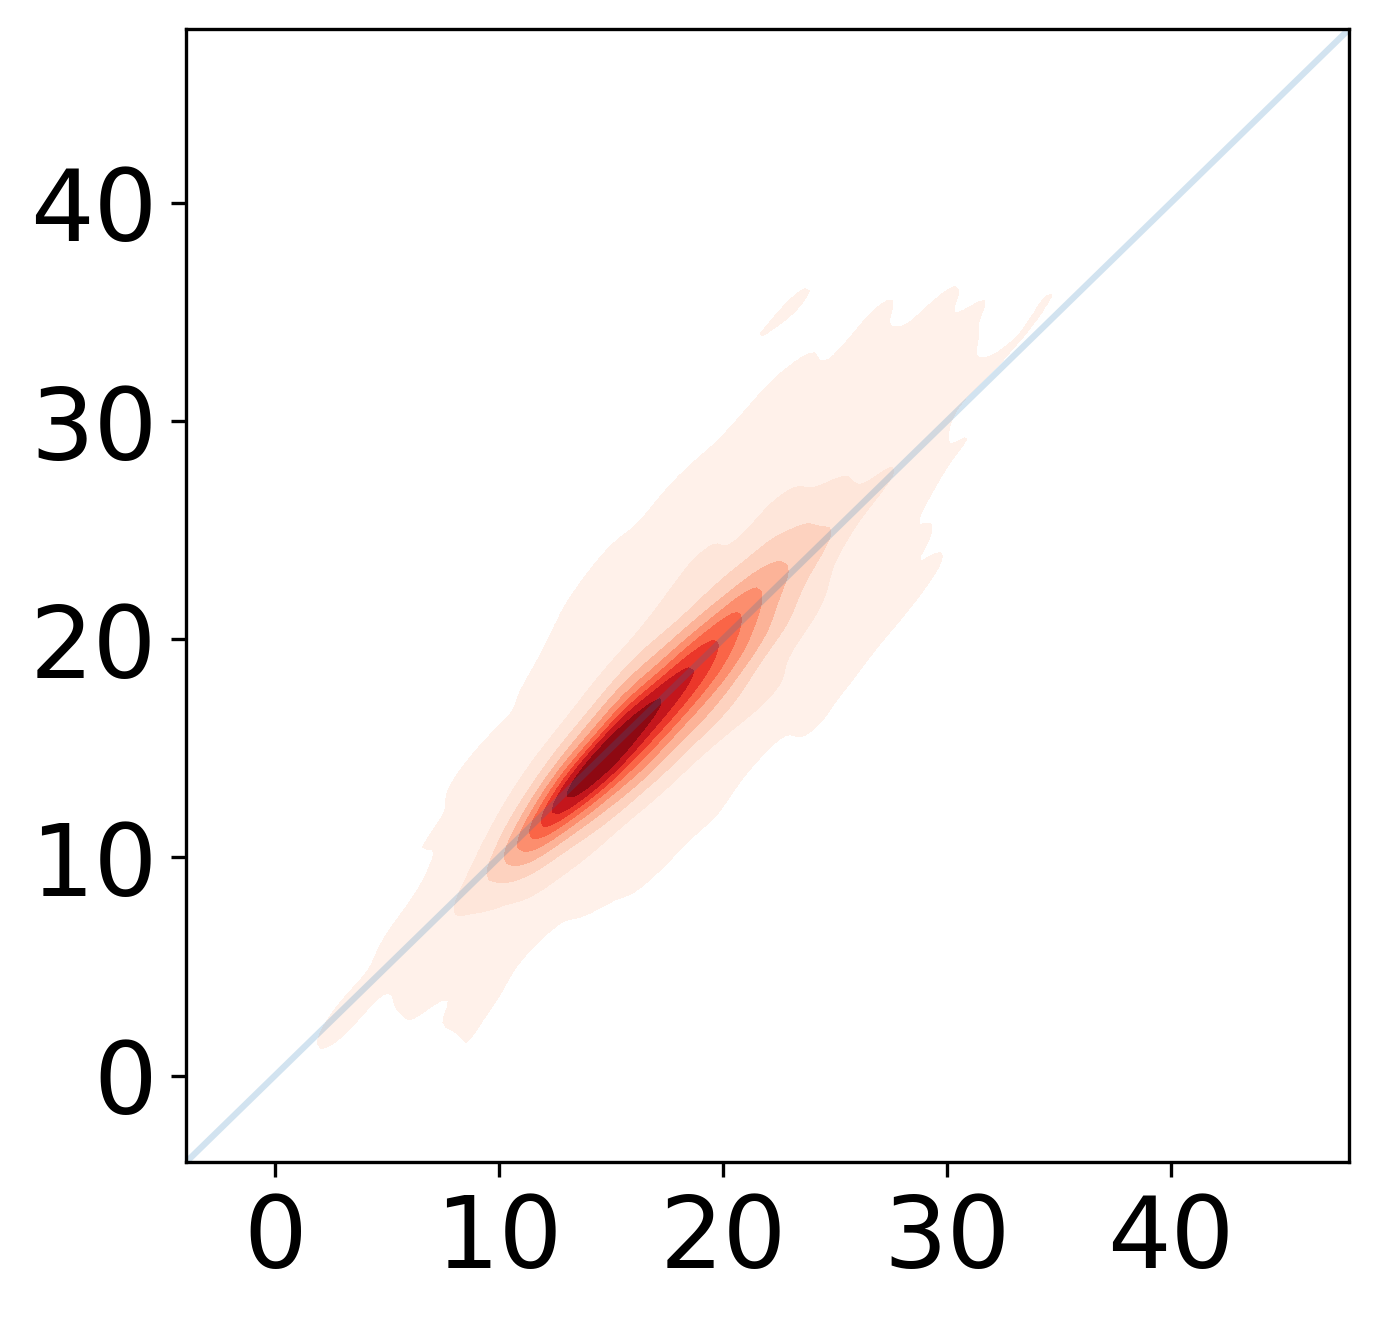

In [30]:
# Interaction
model_train.plot_scatter_with_metrics(IN_Pred, Y_IN, alpha=0.01)

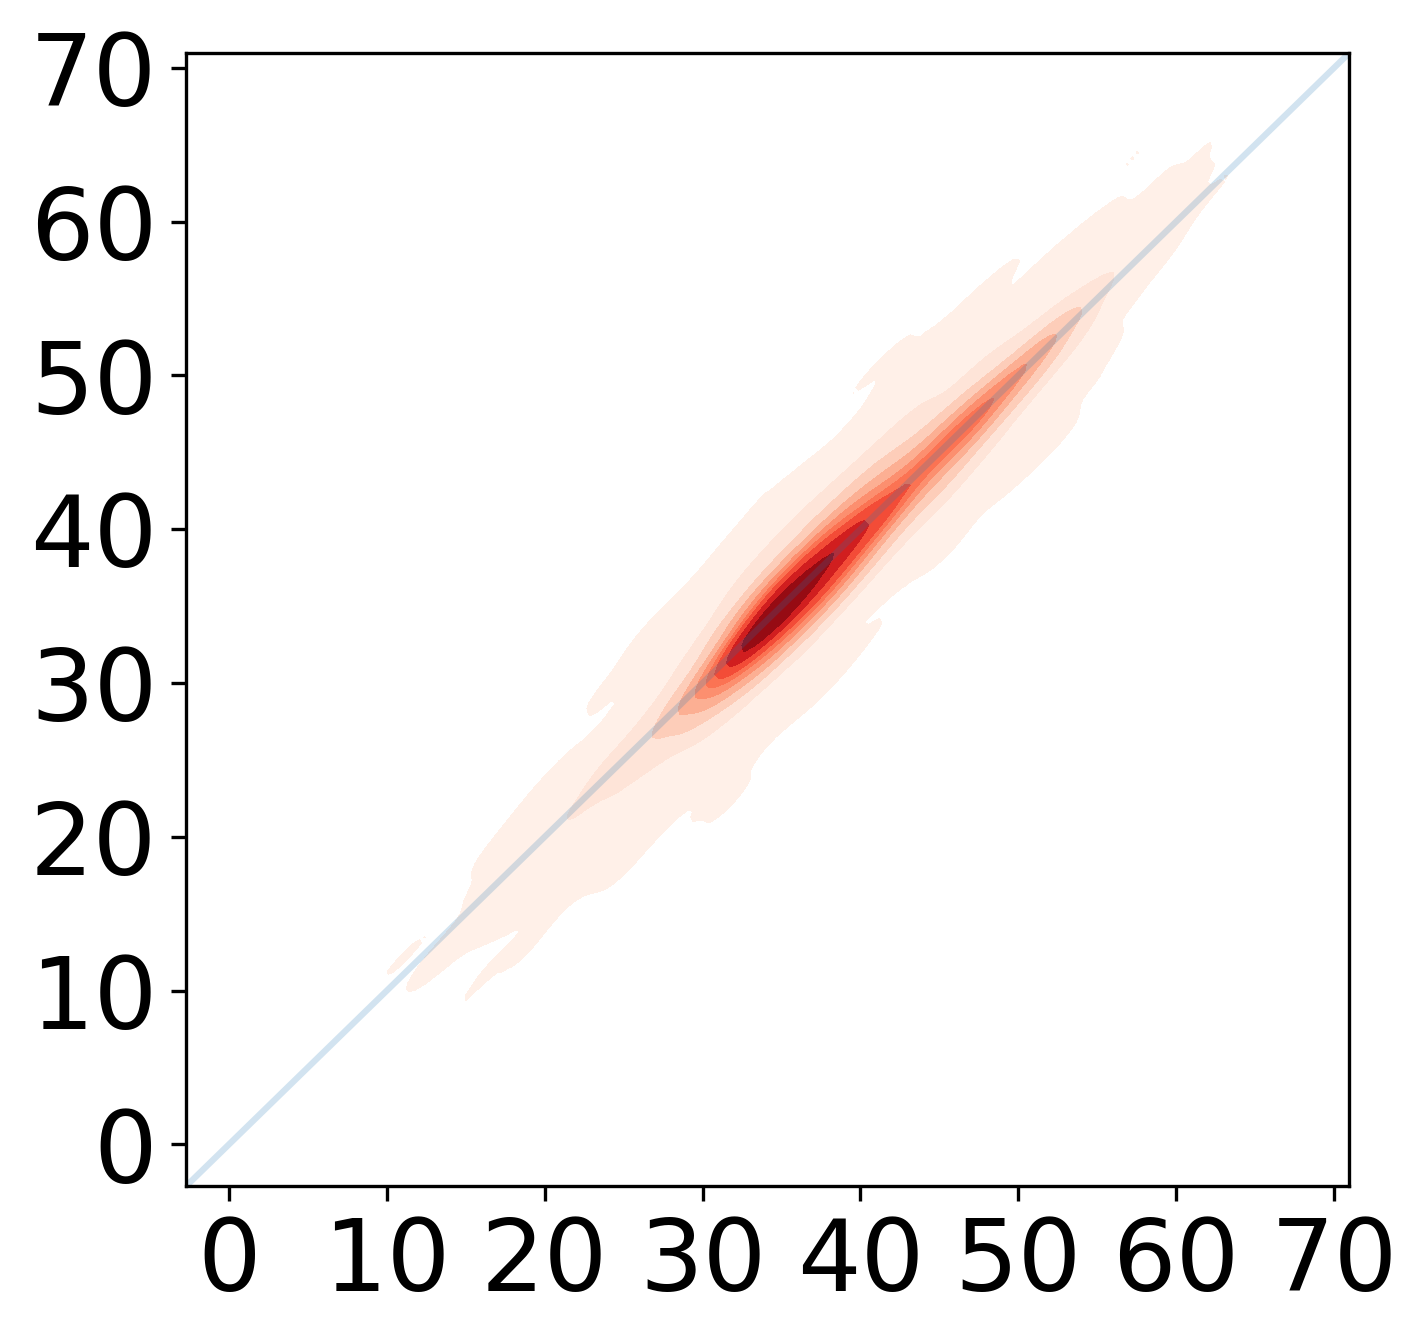

In [32]:
# deltaGa
model_train.plot_scatter_with_metrics(G_Pred, Y_Ga, alpha=0.01)

### Other Model for ablation study

In [ ]:
# Poor Model(PhysOrg)
k = KFold(n_splits=5, shuffle=True, random_state=0).split(X_Ga)

all_y_preds = []
all_y_trues = []
Y_labels = [Y_DD, Y_ED, Y_IN, Y_Ga]
for train_ids, test_ids, train_ids_G in k:
    all_y_pred = []
    all_y_true = []
    X_removed = X_Ga[:, :48]
    for y_id, Y_target in enumerate([Y_DD, Y_ED, Y_IN, Y_Ga]):
        X_train = X_removed[train_ids]
        X_test = X_removed[test_ids]

        model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
        model.fit(X_train, Y_target[train_ids])
        y_pred = model.predict(X_test)
        all_y_pred.append(y_pred)
        all_y_true.append(Y_target[test_ids])
        print(model_train.r2_score(Y_target[test_ids], y_pred))
    all_y_preds.append(all_y_pred)
    all_y_trues.append(all_y_true)

r2_score, mae, mse = [[] for _ in range(4)], [[] for _ in range(4)], [[] for _ in range(4)]
for [all_y_pred, all_y_true] in zip(all_y_preds, all_y_trues):
    y_dd_pred, y_ed_pred, y_in_pred, y_g_pred = all_y_pred
    y_dd_true, y_ed_true, y_in_true, y_g_true = all_y_true
    for y_id, [y_true, y_pred] in enumerate(zip([y_dd_true, y_ed_true, y_in_true, y_g_true], 
                                                [y_dd_pred, y_ed_pred, y_in_pred, y_g_pred])):
        r2_score[y_id].append(model_train.r2_score(y_true, y_pred))
        mae[y_id].append(model_train.mean_absolute_error(y_true, y_pred))
        mse[y_id].append(model_train.mean_squared_error(y_true, y_pred))
rmse = np.sqrt(mse)
print(["4π Distortion", "2π Distortion", "Interaction", "Active Energy"])
print(np.array(r2_score).mean(axis=1))
print(np.array(mae).mean(axis=1))
print(np.array(mse).mean(axis=1))
print(np.array(rmse).mean(axis=1))

In [ ]:
# +SVO Model(PhysOrg + SVO)
k = KFold(n_splits=5, shuffle=True, random_state=0).split(X_Ga)

all_y_preds = []
all_y_trues = []
Y_labels = [Y_DD, Y_ED, Y_IN, Y_Ga]
for train_ids, test_ids, train_ids_G in k:
    all_y_pred = []
    all_y_true = []
    X_removed = X_Ga
    for y_id, Y_target in enumerate([Y_DD, Y_ED, Y_IN, Y_Ga]):
        X_train = X_removed[train_ids]
        X_test = X_removed[test_ids]
        model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
        model.fit(X_train, Y_target[train_ids])
        y_pred = model.predict(X_test)
        all_y_pred.append(y_pred)
        all_y_true.append(Y_target[test_ids])
        print(model_train.r2_score(Y_target[test_ids], y_pred))
    all_y_preds.append(all_y_pred)
    all_y_trues.append(all_y_true)

r2_score, mae, mse = [[] for _ in range(4)], [[] for _ in range(4)], [[] for _ in range(4)]
for [all_y_pred, all_y_true] in zip(all_y_preds, all_y_trues):
    y_dd_pred, y_ed_pred, y_in_pred, y_g_pred = all_y_pred
    y_dd_true, y_ed_true, y_in_true, y_g_true = all_y_true
    for y_id, [y_true, y_pred] in enumerate(zip([y_dd_true, y_ed_true, y_in_true, y_g_true], 
                                                [y_dd_pred, y_ed_pred, y_in_pred, y_g_pred])):
        r2_score[y_id].append(model_train.r2_score(y_true, y_pred))
        mae[y_id].append(model_train.mean_absolute_error(y_true, y_pred))
        mse[y_id].append(model_train.mean_squared_error(y_true, y_pred))
rmse = np.sqrt(mse)
print(["4π Distortion", "2π Distortion", "Interaction", "Active Energy"])
print(np.array(r2_score).mean(axis=1))
print(np.array(mae).mean(axis=1))
print(np.array(mse).mean(axis=1))
print(np.array(rmse).mean(axis=1))

### Result
#### Poor Model (PhysOrg)
[0.9372214  0.82355707 0.78631763 0.92279108]
[1.08658727 1.15255578 1.56234679 1.58751902]
[2.34027415 2.5539158  4.96364815 4.73316775]
[1.52966974 1.5974534  2.22776674 2.17436764]
 #### PhysOrg + SVO
[0.93363169 0.81554522 0.78609412 0.90947805 0.90925507 0.68039629
 0.91414611 0.91167502]
[1.11744794 1.18003209 1.57015876 1.60577745 1.60380698 1.14099236
 1.6581528  1.68688305]
[2.47430829 2.66717839 4.9709583  4.98704068 4.99976656 2.62917548
 5.26308172 5.41462436]
[1.57282449 1.63279824 2.2293949  2.23238405 2.23500208 1.62111258
 2.29287292 2.32595153]
#### Full (PhysOrg + SVO + deltaGrxn)
[0.93675778 0.82360676 0.7863947  0.91707887 0.91777296 0.68121181
 0.92297604 0.92128071]
[1.08928023 1.15335966 1.56740609 1.53859087 1.53231497 1.1405368
 1.5796423  1.60426598]
[2.35723122 2.55340886 4.96254148 4.56920823 4.53053105 2.62270402
 4.72229187 4.8265403 ]
[1.53523985 1.59730479 2.227546   2.13642792 2.12749729 1.61916312
 2.17179724 2.19593634]

## 2.4 Feature Importance

In [40]:
train_ids_G = get_train_ids(range(len(X_Ga)))
Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
Gmodel.fit(X_G[train_ids_G], Y_G_data_G[train_ids_G])
predG = Gmodel.predict(X_Ga)
X_removed = np.hstack([X_Ga, predG.reshape(-1, 1)])
all_feature_importance = []
for y_id, y_true in enumerate([Y_DD, Y_ED, Y_IN, Y_Ga]):
    model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
    model.fit(X_removed, y_true)
    all_feature_importance.append(model.feature_importances_)
all_feature_importance = np.array(all_feature_importance)
print(all_feature_importance)
### Result
#### Poor Model (PhysOrg)

[[ 1.81708619  3.31942186  1.59714705  0.98810473  0.90336738  0.39248237
   0.43811195  0.46822936  0.43366047  4.41740479  1.5577972  10.90022745
   2.84525888  9.09384493  4.1790188   0.41434758  1.5616624   0.45505679
   0.35910898  3.57987253  1.56563637  0.55116089  2.48747195  0.97573663
   0.3509586   0.50272649  0.34273054  0.43686096  0.25736789  0.26031763
   0.38218562  0.43569312  0.26987521  0.39762802  1.04755034  0.60033518
   1.16963981  0.22746019  0.21322483  0.33164152  0.27377916  0.62698034
   0.38382005  0.26387057  0.26719917  0.34281674  0.45060833  0.51932763
   1.79037038 10.67730925  0.44390542  0.35829409  1.37139944  2.65591221
   0.40308572  0.42163348  0.34484533  0.30291033  0.30352847  0.31771346
   0.35134704  0.27834678  0.28236551  0.26731746 13.77390017]
 [ 0.52054573  0.26296153  0.30098593  0.32001966  0.32118774  0.88770562
   0.4282754   0.6186848   0.46392632  0.42768196  0.78617701  1.47271959
   1.62904711  1.70381072  0.42751844  0.29898611

In [46]:
all_feature_name = np.array(model_train.ALL_PROPERTIES_diene + model_train.ALL_PROPERTIES_ene + model_train.New_des + ['deltaG_pred'])
sorted_feature_importance = all_feature_importance.argsort()[::-1]
for each in sorted_feature_importance:
    print(all_feature_name[each[-10:]])

['ene_min_angle_cos' 'diene_max_neighbor_charge' 'ene_max_angle_cos'
 'diene_lumo+1' 'diene_area_1' 'ene_lumo' 'diene_lumo' 'distance_ad'
 'angle_b_cos' 'deltaG_pred']
['ene_dipole' 'diene_lumo' 'diene_max_charge' 'ene_min_angle_cos'
 'ene_max_neighbor_charge' 'deltaG_pred' 'diene_area_4' 'diene_charge_d'
 'bond2' 'ene_lumo']
['ene_area_4' 'ene_max_neighbor_charge' 'min_ene_L' 'max_ene_B1'
 'ene_min_angle_cos' 'ene_max_angle_cos' 'min_ene_B1' 'ene_charge_e'
 'ene_charge_f' 'deltaG_pred']
['diene_area_5' 'angle_a_cos' 'diene_charge_b' 'diene_lumo'
 'diene_max_angle_cos' 'bond2' 'angle_b_cos' 'diene_area_1' 'distance_ad'
 'deltaG_pred']


# 3 Performance Between PhysOrg Descriptor and Molecular Fingerprint

## 3.1 Generate All Descriptors

### 3.1.1 # PhysOrg Descriptor

In [6]:
# PhysOrg
data_G = pd.read_csv(DATA_G_FILE)
data_Ga = pd.read_csv(DATA_GA_FILE)
X_G, _ = model_train.read_df(data_G, QM_MAP)
X_Ga, _ = model_train.read_df(data_Ga, QM_MAP)
Y_DD = data_Ga['Diene_Distort'].to_numpy()
Y_ED = data_Ga['Ene_Distort'].to_numpy()
Y_IN = data_Ga['Interaction'].to_numpy()
Y_Ga = data_Ga['deltaGa(Solvent)'].to_numpy()
Y_G_data_G = data_G['deltaG']
Y_G = data_Ga['deltaG']

100%|██████████| 8273/8273 [00:01<00:00, 5728.70it/s]


### 3.1.2 Generate 2D MF

In [ ]:
gen_2D = gendes.generate2Ddesc(data_Ga, has_product=1)
rd_mf_map = gen_2D.calc_rdkit_mf()
rd_des_map = gen_2D.calc_rdkit_desc()
morgan_map = gen_2D.calc_morgan_mf()
modred_map = gen_2D.calc_modred_desc()

### 3.1.3 Generate 3D MF

In [ ]:
gen_3D = gendes.generate3Ddesc(data_Ga, mol_dir=r"G:\work\Secondary_Selection\Diene_Ene_Smiles\mol")
acsf_3D_map = gen_3D.calc_acsf_desc()
soap_3D_map = gen_3D.calc_soap_desc()
mbtr_3D_map = gen_3D.calc_mbtr_desc()
lmbtr_3D_map = gen_3D.calc_lmbtr_desc()

Generate Mols: 8277it [01:06, 124.47it/s]
Generate ACSF: 9560it [00:12, 791.35it/s]
Generate SOAP: 9560it [00:01, 7646.31it/s]
Generate MBTR: 9560it [03:14, 49.13it/s] 
Generate LMBTR: 9560it [00:37, 252.82it/s]


In [11]:
with open(CSV_FILE_DIR + "/" + r"Descriptors\ZINC_fp_map.pkl", 'wb')as f:
    pickle.dump([rd_mf_map, rd_des_map, morgan_map, modred_map, acsf_3D_map, soap_3D_map, mbtr_3D_map, lmbtr_3D_map], f)

In [6]:
with open(CSV_FILE_DIR + "/" + r"Descriptors\ZINC_fp_map.pkl", 'rb')as f:
    rd_mf_map, rd_des_map, morgan_map, modred_map, acsf_3D_map, soap_3D_map, mbtr_3D_map, lmbtr_3D_map = pickle.load(f)

### 3.1.4 Generate Pretrain MF

In [12]:
all_smiles = gen_3D.smi_set
all_mols = gen_3D.mol_set
with open("all_smi.pkl", 'wb') as f:
    pickle.dump(all_smiles, f)
with open("all_mol.pkl", 'wb') as f:
    pickle.dump(all_mols, f)

Generate By 

In [15]:
with open(CSV_FILE_DIR + "/" + r"Descriptors\smiles_vae_map.pkl", 'rb')as f:
    smiles_vae_map = pickle.load(f)
with open(CSV_FILE_DIR + "/" + r"Descriptors\smiles_trfm_map.pkl", 'rb')as f:
    smiles_trfm_map = pickle.load(f)
with open(CSV_FILE_DIR + "/" + r"Descriptors\graph_gae_map.pkl", 'rb')as f:
    graph_gae_map = pickle.load(f)

### 3.1.5 Convert Descriptor to array

In [92]:
X_rddes, _, _ = model_train.descriptor_generator([data_Ga], rd_des_map, 1, 0, 1, 0, "deltaEa", is_3d_map=0)
X_morgan, _, _ = model_train.descriptor_generator([data_Ga], morgan_map, 1, 0, 1, 0, "deltaEa" , is_3d_map=0)
X_rdmf, _, _ = model_train.descriptor_generator([data_Ga], rd_mf_map, 1, 0, 1, 0, "deltaEa" , is_3d_map=0)
X_modred, _, _ = model_train.descriptor_generator([data_Ga], modred_map, 1, 0, 1, 0, "deltaEa" , is_3d_map=0)
X_acsf, Y_DD, _ = model_train.descriptor_generator([data_Ga], acsf_3D_map, 1, 0, 1, 0, "Diene_Distort" , is_3d_map=1)
X_soap, _, _ = model_train.descriptor_generator([data_Ga], soap_3D_map, 1, 0, 1, 0, "Diene_Distort" , is_3d_map=1)
X_lmbtr, _, _ = model_train.descriptor_generator([data_Ga], lmbtr_3D_map, 1, 0, 1, 0, "Diene_Distort" , is_3d_map=1)
X_mbtr, _, _ = model_train.descriptor_generator([data_Ga], mbtr_3D_map, 1, 0, 1, 0, "Diene_Distort" , is_3d_map=1)
X_vae, Y_ED, _ = model_train.descriptor_generator([data_Ga], smiles_vae_map, 1, 0, 1, 0, "Ene_Distort" , is_3d_map=1)
X_trfm, _, _ = model_train.descriptor_generator([data_Ga], smiles_trfm_map, 1, 0, 1, 0, "Ene_Distort" , is_3d_map=1)
X_gae, _, _ = model_train.descriptor_generator([data_Ga], graph_gae_map, 1, 0, 1, 0, "Ene_Distort" , is_3d_map=1)

100%|██████████| 8273/8273 [00:02<00:00, 3723.80it/s]


In [43]:
X = X_Ga
all_fp = [X_rddes, X_morgan, X_rdmf, X_modred, X_acsf, X_soap, X_lmbtr, X_mbtr, X_vae, X_trfm, X_gae, X]

### 3.1.6 Save/Load Fingerprint

In [15]:
with open(CSV_FILE_DIR + "/" + r"Descriptors\ZINC_fp_DIDE.pkl", 'wb') as f:
    pickle.dump(all_fp, f)
with open(CSV_FILE_DIR + "/" + r"Descriptors\ZINC_Y_DIDE.pkl", 'wb') as f:
    pickle.dump([Y_DD, Y_ED, Y_IN, Y_Ga], f)

In [12]:
with open(CSV_FILE_DIR + "/" + r"Descriptors/ZINC_fp_DIDE.pkl", 'rb') as f:
    all_fp = pickle.load(f) 
with open(CSV_FILE_DIR + "/" + r"Descriptors/ZINC_Y_DIDE.pkl", 'rb') as f:
    Y_DD, Y_ED, Y_IN, Y_Ga = pickle.load(f)
X_rddes, X_morgan, X_rdmf, X_modred, X_acsf, X_soap, X_lmbtr, X_mbtr, X_vae, X_trfm, X_gae, X = all_fp

## 3.2 FingerPrint Selection

In [31]:
n_est_list = [100, 200,300]
max_depth_list = [2,3,4,5,6]
mss_list = [2,3,4,5,6]
msl_list = [1,2,3,4]
GB_space = {"n_estimators": hp.choice("n_estimators", n_est_list), 
         "min_samples_split": hp.choice("min_samples_split", mss_list), 
         "min_samples_leaf": hp.choice("min_samples_leaf", msl_list)}
GB_hyper = [n_est_list, mss_list, msl_list]
ADB_space = {"n_estimators": hp.choice("n_estimators", n_est_list),}
ADB_hyper = [n_est_list]
XGB_space = {"n_estimators": hp.choice("n_estimators", n_est_list), 
            "max_depth": hp.choice("max_depth", max_depth_list),}
XGB_hyper = [n_est_list, max_depth_list]
RF_ET_space = {"n_estimators": hp.choice("n_estimators", n_est_list), 
         "min_samples_split": hp.choice("min_samples_split", mss_list), 
         "min_samples_leaf": hp.choice("min_samples_leaf", msl_list)}
RF_ET_hyper = [n_est_list, mss_list, msl_list]
RIDGE_Lasso_SGD_space = {"alpha": hp.choice("alpha", [0,0.5,1])}
RIDGE_Lasso_SGD_hyper = [[0,0.5,1]]
br_list = [1e-7, 1e-6, 1e-5]
BR_space = {"alpha_1": hp.choice("alpha_1", br_list), "alpha_2": hp.choice("alpha_2", br_list),
"lambda_1": hp.choice("lambda_1", br_list), "lambda_2": hp.choice("lambda_2", br_list)}
BR_hyper = 	[br_list, br_list, br_list, br_list]
SVR_space = {"C": hp.choice("C", [0,0.5,1]), "epsilon":hp.choice("epsilon", [0.1,0.2,0.3])}
SVR_hyper = [[0,0.5,1], [0.1,0.2,0.3]]
KNN_space = {"n_neighbors": hp.choice("n_neighbors", [1,2,3,4,5,6,7,8,9,10])}
KNN_hyper = [[1,2,3,4,5,6,7,8,9,10]]

In [32]:
models = [
    GradientBoostingRegressor, 
    RandomForestRegressor, 
    AdaBoostRegressor,
    ExtraTreesRegressor,
    XGBRegressor,
    Lasso,
    Ridge, 
    BayesianRidge,
    SGDRegressor,
    SVR,
    KNeighborsRegressor,
    ]
spaces = [GB_space, RF_ET_space, ADB_space, RF_ET_space, XGB_space, RIDGE_Lasso_SGD_space, RIDGE_Lasso_SGD_space, BR_space, RIDGE_Lasso_SGD_space, SVR_space, KNN_space]
hypers = [GB_hyper, RF_ET_hyper, ADB_hyper, RF_ET_hyper, XGB_hyper, RIDGE_Lasso_SGD_hyper, RIDGE_Lasso_SGD_hyper, BR_hyper, RIDGE_Lasso_SGD_hyper, SVR_hyper, KNN_hyper]
model_names = ["GB", "RF", "ADB", "ET", "LASSO", "RIDGE", "BR", "SGD", "SVR", "KNN"]

In [18]:
from sklearn.decomposition import PCA
all_fp = [X, X_rddes, X_morgan, X_rdmf, X_modred, X_acsf, X_soap, X_lmbtr, X_mbtr, X_vae, X_trfm, X_gae]
all_fp = [X]
all_fp_pca = []
for fp in tqdm(all_fp):
    if fp.shape[1] < 300:
        all_fp_pca.append(fp)
    else:
        pca = PCA(n_components=300, whiten=True, svd_solver='auto', random_state=0)
        all_fp_pca.append(pca.fit_transform(fp))
for fp_pca in all_fp_pca:
    print(fp_pca.shape)

100%|██████████| 1/1 [00:00<?, ?it/s]

(8273, 64)


In [48]:
Y = Y_DD # Y_ED, Y_IN, Y_Ga
DD_sum_r2 = model_train.benchmark(all_fp_pca, Y, data= data_Ga,models=models, spaces=spaces, hyperparams=hypers,epoch_time=1, reverse_train_test=0, name='4pD_pca300_1', max_evals=20)

start
Epoch : 0           
100%|██████████| 20/20 [02:29<00:00,  7.47s/trial, best loss: -0.8627932156218552]
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>   {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4}
0.9058440711521045_1.3842553668624202
0.9022368385689016_1.4078338780527508
0.9063187004032464_1.3688676006757647
0.9084443021160344_1.4129523815336742
0.903854095091537_1.4168470922336975
0, 0, 0.9053396014663647, 1.3981512638716613
100%|██████████| 20/20 [06:38<00:00, 19.94s/trial, best loss: -0.8051157626412595]
<class 'sklearn.ensemble._forest.RandomForestRegressor'>   {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1}
0.9084771573214077_1.267812284126889
0.8928934613275569_1.3217451775492663
0.9075292133332309_1.2165150875951496
0.910975504251365_1.283289989475349
0.909421132942908_1.270179372327802
1, 0, 0.9058592938352937, 1.271908382214891
100%|██████████| 20/20 [01:26<00:00,  4.34s/trial, best loss: -0.6878293151108106]
<clas

In [51]:
## RF Select model+
Y = Y_ED # Y_ED, Y_IN, Y_Ga
DD_sum_r2 = model_train.benchmark(all_fp_pca, Y, data= data_Ga,models=models, spaces=spaces, hyperparams=hypers,epoch_time=1, reverse_train_test=0, name='2pD_pca300_1', max_evals=20)

start
Epoch : 0           
100%|██████████| 20/20 [04:01<00:00, 12.08s/trial, best loss: -0.6774625921201116]
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>   {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 3}
0.7386996022261675_1.4170366162054535
0.758981646221051_1.4511716511708646
0.7531921949893978_1.4812180164866777
0.7439264986274527_1.4239414235893202
0.7328458710787664_1.4743695790554514
0, 0, 0.7455291626285672, 1.4495474573015534
100%|██████████| 20/20 [07:04<00:00, 21.20s/trial, best loss: -0.6198819484271734]
<class 'sklearn.ensemble._forest.RandomForestRegressor'>   {'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 1}
0.7626600033124825_1.3028920004420446
0.7638116491597805_1.3652805151067786
0.7526728706398993_1.401515401005807
0.7503443702749267_1.3420161036471305
0.741671607315415_1.3999664951816373
1, 0, 0.7542321001405008, 1.3623341030766796
100%|██████████| 20/20 [01:42<00:00,  5.11s/trial, best loss: -0.40259351867223103]


In [49]:
## RF Select model+
Y = Y_IN # Y_ED, Y_IN, Y_Ga
DD_sum_r2 = model_train.benchmark(all_fp_pca, Y, data= data_Ga,models=models, spaces=spaces, hyperparams=hypers,epoch_time=1, reverse_train_test=0, name='Int_pca300_1', max_evals=20)

start
Epoch : 0           
100%|██████████| 20/20 [02:30<00:00,  7.53s/trial, best loss: -0.6515130737301313]
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>   {'n_estimators': 300, 'min_samples_split': 6, 'min_samples_leaf': 2}
0.7436508275353404_1.8156381666714687
0.7186157124388448_1.8798068980943181
0.7313295226090948_1.8772508654424296
0.7271413216653568_1.8098852471174258
0.7385086261489548_1.8025123201330728
0, 0, 0.7318492020795184, 1.8370186994917428
100%|██████████| 20/20 [06:55<00:00, 20.78s/trial, best loss: -0.5972522600822923]
<class 'sklearn.ensemble._forest.RandomForestRegressor'>   {'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 2}
0.7491847602801842_1.732503583036924
0.7370120980903053_1.7135156331688894
0.7207726409561062_1.7953273192405446
0.7288029271652119_1.721091357488994
0.735537014923695_1.7313632333038633
1, 0, 0.7342618882831005, 1.7387602252478431
100%|██████████| 20/20 [01:30<00:00,  4.51s/trial, best loss: -0.3416353861373829]
<

In [50]:
## RF Select model+
Y = Y_Ga # Y_ED, Y_IN, Y_Ga
DD_sum_r2 = model_train.benchmark(all_fp_pca, Y, data= data_Ga,models=models, spaces=spaces, hyperparams=hypers,epoch_time=1, reverse_train_test=0, name='G_pca300_1', max_evals=20)

start
Epoch : 0           
100%|██████████| 20/20 [02:45<00:00,  8.28s/trial, best loss: -0.80578670245666]
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>   {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4}
0.8622418411038348_2.1840907405642476
0.8683835506754745_2.1607983430722464
0.8730304400401343_2.133479539680049
0.8681060175662179_2.1378627697776618
0.8553819141181942_2.214072889273032
0, 0, 0.865428752700771, 2.1660608564734476
100%|██████████| 20/20 [07:09<00:00, 21.49s/trial, best loss: -0.7404347705320153]
<class 'sklearn.ensemble._forest.RandomForestRegressor'>   {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 1}
0.8688244834132399_1.9497323017201456
0.8765351257227892_1.9415829736853207
0.8809544106400004_1.934902277453925
0.873976513528854_1.9548529240505093
0.8651620987985592_2.05490410211322
1, 0, 0.8730905264206885, 1.9671949158046238
100%|██████████| 20/20 [01:38<00:00,  4.92s/trial, best loss: -0.6047667834340812]
<class 

In [ ]:
# With Catboost Model
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
Y = Y_DD # Y_ED, Y_IN, Y_Ga
all_mae = []
kf = KFold(n_splits=5, shuffle=True, random_state=0).split(fp)
all_r2 = []
fp = all_fp_pca[-1]
for each in kf:
    model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
    train_id, test_id = each
    x_train, y_train = fp[train_id], Y[train_id]
    x_test, y_test = fp[test_id], Y[test_id]
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    all_r2.append(r2_score(y_test, y_pred))
    all_mae.append(mae)
print(np.mean(all_mae))

# 4 Performance of Other Models

## Performance of deltaGrxn Prediction Model

In [9]:
# 5-Fold Test on over 50000 datasets
from sklearn.model_selection import KFold, cross_val_score
k = KFold(n_splits=5, shuffle=True, random_state=0).split(X_G)
# k = model_train.special_k_fold(data_Ga, 5, seed=0, special=True)
# k = [[a,b, get_train_ids(b)] for a,b in k]
all_r2s = []
all_mae = []
pred_G, real_G = [], []
for train_ids, test_ids in k:
    Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
    Gmodel.fit(X_G[train_ids], Y_G_data_G[train_ids])
    predG = Gmodel.predict(X_G[test_ids])
    all_r2s.append(model_train.r2_score(Y_G_data_G[test_ids], predG))
    all_mae.append(model_train.mean_absolute_error(Y_G_data_G[test_ids], predG))
    pred_G.append(predG)
    real_G.append(Y_G_data_G[test_ids])

print(np.array(all_r2s).mean())
print(np.array(all_mae).mean())
model_train.plot_scatter_with_metrics(real_G, pred_G,max_=150, min_=-100, alpha=1)

0.9826875046417209
2.4423888904201263


In [ ]:
# 5-Fold Test on 8273 datasets (With Active Energy)
from sklearn.model_selection import KFold, cross_val_score
k = KFold(n_splits=5, shuffle=True, random_state=0).split(X_Ga)
all_r2s = []
all_mae = []
pred_G, real_G = [], []
for train_ids, test_ids in k:
    Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
    Gmodel.fit(X_Ga[train_ids], Y_G[train_ids])
    predG = Gmodel.predict(X_Ga[test_ids])
    all_r2s.append(model_train.r2_score(Y_G[test_ids], predG))
    all_mae.append(model_train.mean_absolute_error(Y_G[test_ids], predG))
    pred_G.append(predG)
    real_G.append(Y_G[test_ids])

print(np.array(all_r2s).mean())
print(np.array(all_mae).mean())
model_train.plot_scatter_with_metrics(real_G, pred_G,max_=20, min_=-100, alpha=1)

## OOS

In [47]:
def OOD_train_test(data, seed=0):
    np.random.seed(seed)
    diene_indexs = np.sort(np.unique(data['Diene_Index'].to_numpy()))
    ene_indexs = np.sort(np.unique(data['Ene_Index'].to_numpy()))
    np.random.shuffle(diene_indexs)
    np.random.shuffle(ene_indexs)
    removed_dienes = diene_indexs[:len(diene_indexs) // 10]
    removed_enes = ene_indexs[:len(ene_indexs) // 10]
    train_ids = [row_id for row_id, row in data.iterrows() if row["Diene_Index"] not in removed_dienes and row["Ene_Index"] not in removed_enes]
    test_ids = [row_id for row_id, row in data.iterrows() if row["Diene_Index"] in removed_dienes and row["Ene_Index"] in removed_enes]
    train_ids = [row_id for row_id, row in data.iterrows() if row["Diene_Index"] not in removed_dienes]
    test_ids = [row_id for row_id, row in data.iterrows() if row["Diene_Index"] in removed_dienes]
    len(train_ids), len(test_ids)
    return train_ids, test_ids

### OOS of deltaGrxn Prediction Model

In [ ]:
train_ids, test_ids = OOD_train_test(data_G)

In [14]:
# OOD of deltaGrxn prediction in over 50000 datasets
Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
Gmodel.fit(X_G[train_ids], Y_G_data_G[train_ids])
predG = Gmodel.predict(X_G[test_ids])
print("R2: ", r2_score(Y_G_data_G[test_ids], predG), "MAE", mean_absolute_error(Y_G_data_G[test_ids], predG))
model_train.plot_scatter_with_metrics(Y_G_data_G[test_ids], predG,max_=150, min_=-100, alpha=1)

(0.920126349439543, 5.952206811177701)

In [29]:
# OOD of deltaGrxn prediction in 8273 datasets
Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
Gmodel.fit(X_Ga[train_ids], Y_G[train_ids])
predG = Gmodel.predict(X_Ga[test_ids])
r2_score(Y_G[test_ids], predG), mean_absolute_error(Y_G[test_ids], predG)

0.47315409612649073

In [26]:
# OOD of deltaGrxn prediction in 8273 datasets with the assistance of over 50000 datasets
train_ids_G = get_train_ids(test_ids)
Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
Gmodel.fit(X_G[train_ids_G], Y_G_data_G[train_ids_G])
predG = Gmodel.predict(X_Ga[test_ids])
r2_score(Y_G[test_ids], predG), mean_absolute_error(Y_G[test_ids], predG)

0.7221970140335019

### OOD of DI Energy and Active Energy

In [48]:
train_ids, test_ids = OOD_train_test(data_Ga, 0)

In [54]:
train_ids, test_ids = model_train.special_k_fold(data_Ga, 5, 0, True)[0]

In [16]:
# PhysOrg + SVO + deltaGrxn (Prediction Model Train by over 50000 Datasets)
train_ids_G = get_train_ids(test_ids)
Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
Gmodel.fit(X_G[train_ids_G], Y_G_data_G[train_ids_G])
predG = Gmodel.predict(X_Ga)
X_removed = np.hstack([X_Ga, predG.reshape(-1, 1)])
all_y_pred = []
all_y_true = []
for y_id, Y_target in enumerate([Y_DD, Y_ED, Y_IN, Y_Ga]):
    X_train = X_removed[train_ids]
    X_test = X_removed[test_ids]
    model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
    model.fit(X_train, Y_target[train_ids])
    y_pred = model.predict(X_test)
    all_y_pred.append(y_pred)
    all_y_true.append(Y_target[test_ids])
    print(model_train.r2_score(Y_target[test_ids], y_pred))

0.704838614542737
0.6817303854059402
0.6519030944163727
0.7671069120044729
0.8027774554747282
0.3584875923469002
0.7634477995112948
0.7638063546020607


In [17]:
# Without deltaGrxn (PhysOrg + SVO)
X_removed = X_Ga
all_y_pred = []
all_y_true = []
for y_id, Y_target in enumerate([Y_DD, Y_ED, Y_IN, Y_Ga]):
    X_train = X_removed[train_ids]
    X_test = X_removed[test_ids]
    model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
    model.fit(X_train, Y_target[train_ids])
    y_pred = model.predict(X_test)
    all_y_pred.append(y_pred)
    all_y_true.append(Y_target[test_ids])
    print(model_train.r2_score(Y_target[test_ids], y_pred))
print(model_train.r2_score(all_y_true[3], all_y_pred[0] + all_y_pred[1] - all_y_pred[2]))
print(model_train.r2_score(all_y_true[4], all_y_pred[0] + all_y_pred[1] - all_y_pred[2] + all_y_pred[5]))

0.5525778778923351
0.627396912319139
0.6450972842429152
0.6520128312614301
0.6953445144284909
0.3473834152552394
0.6186464152980697
0.6130551093636156


In [57]:
# PhysOrg + SVO + deltaGrxn (Prediction Model Train by 8273 Datasets)
all_r2s = np.zeros((5,4))
for fold_id, [train_ids, test_ids] in enumerate(model_train.special_k_fold(data_Ga, 5, 0, True)):
    train_ids_G = get_train_ids(test_ids)
    Gmodel = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
    Gmodel.fit(X_Ga[train_ids], data_Ga['deltaG'][train_ids])
    predG = Gmodel.predict(X_Ga)
    X_removed = np.hstack([X_Ga, predG.reshape(-1, 1)])
    all_y_pred = []
    all_y_true = []
    for y_id, Y_target in enumerate([Y_DD, Y_ED, Y_IN, Y_Ga]):
        X_train = X_removed[train_ids]
        X_test = X_removed[test_ids]
        model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.01, depth=6, verbose=0)
        model.fit(X_train, Y_target[train_ids])
        y_pred = model.predict(X_test)
        all_y_pred.append(y_pred)
        all_y_true.append(Y_target[test_ids])
        print(model_train.r2_score(Y_target[test_ids], y_pred))
        all_r2s[fold_id, y_id] = model_train.r2_score(Y_target[test_ids], y_pred)
all_r2s.mean(axis=0)

0.8960607188944644
0.7154723279086599
0.7051680779640364
0.8428098431066843
0.8782581617602482
0.7019041936936581
0.695148535086662
0.8291287279654797
0.8760938890928642
0.7126396180949269
0.6793510649296937
0.8386229824564205
0.8914068948424528
0.7383175537011922
0.7209096256710139
0.836978621840414
0.8823640318171126
0.7333579767313678
0.7072210822035827
0.8682756330161491


array([0.88483674, 0.72033833, 0.70155968, 0.84316316])

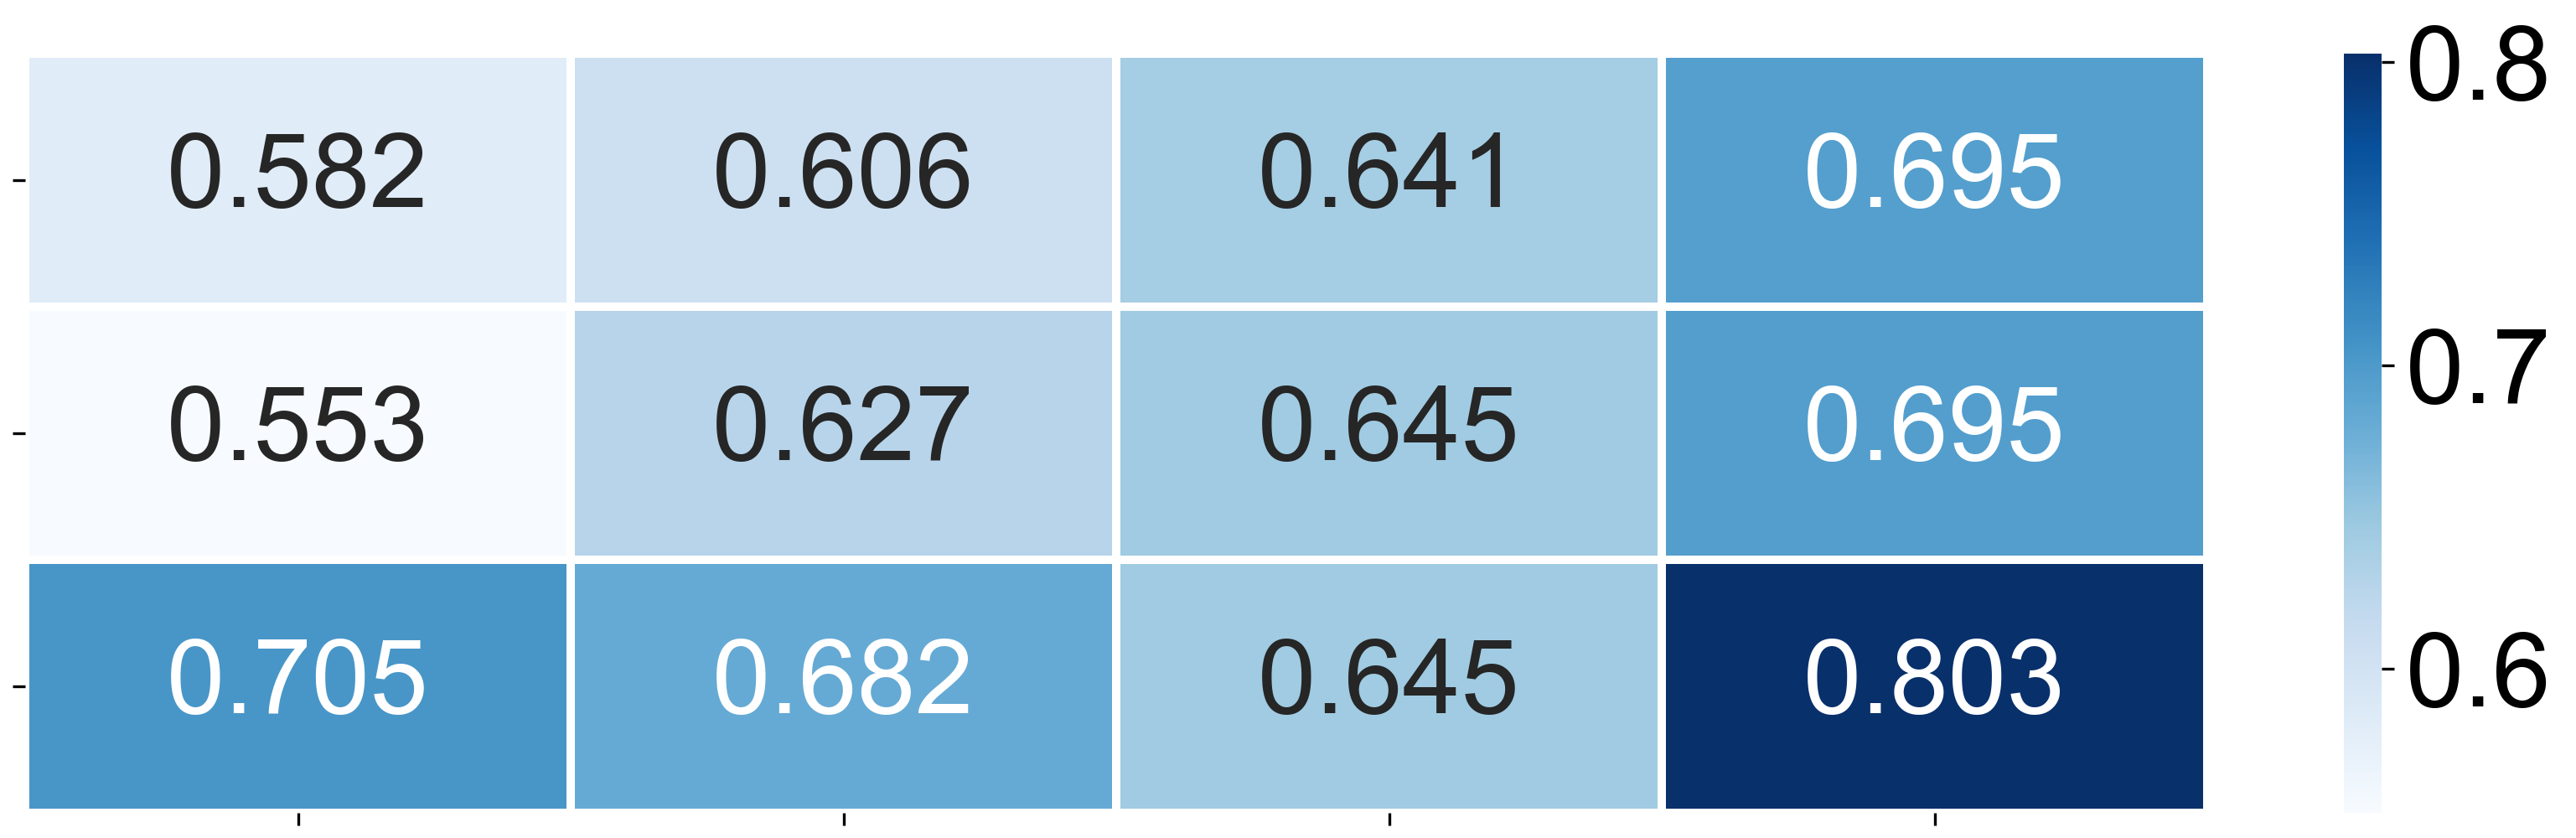

<module 'matplotlib.pyplot' from 'c:\\Users\\Jackie\\anaconda3\\envs\\main\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [60]:
c = [0.704838614542737, 0.6817303854059402, 0.6451362509049359, 0.8027774554747282]
b = [0.5525778778923351, 0.627396912319139, 0.6450972842429152, 0.6953445144284909] 
a = [0.5818087660228446, 0.6060741894561399, 0.6409659612204923, 0.695032384381725]
result = np.array([a,b,c])
model_train.draw_heatmap(values=result, figure_size=(14, 4), colors='Blues')

0.611909434741814
0.6149710213997155
0.6430725822993818
0.6852885057568248
0.6927057806390262
0.39340348542421255
0.6575536517183627
0.654311535285746
G增强
0.7108456789551176
0.6883130533490698
0.6583915985939416
0.7844023469621031
0.8139853868112
0.3805960977800622
0.7658245988778434
0.768799364544143


# Other Figures


## Distribution Used in Figure 3

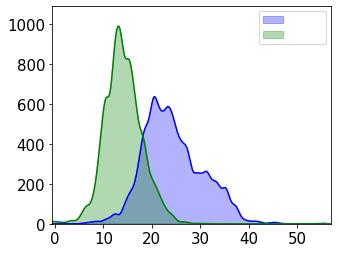

In [19]:
model_train.calc_distribution_line([Y_DD, Y_ED], eachsize=1, ylab=None, return_result = False, labels = ['          ', '          ', 'Int.'])

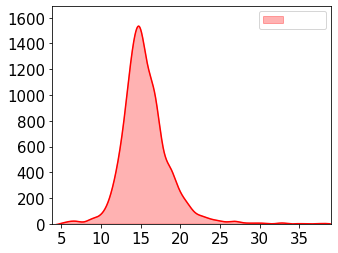

In [7]:
model_train.calc_distribution_line([Y_Ga - Y_E], eachsize=1, ylab=None, return_result = False, labels = ['          '], colors=['red'])

In [ ]:
model_train.calc_distribution_line([-1 * Y_IN], eachsize=1, ylab=None, return_result = False, labels = ['          '], colors=['red'])

In [37]:
def draw_correlationship_figure(x,y):
    min_ = np.min(x) - 15
    max_ = np.max(x) + 15
    plt.figure(figsize=(4, 4))
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    print(model.score(x.reshape(-1, 1), y))
    pred_min, pred_max = model.predict([[min_], [max_]])
    plt.plot([min_, max_], [pred_min, pred_max], c='blue')
    plt.scatter(x, y, marker="*", c="g", s=1)
    plt.savefig("test.png", dpi=300, bbox_inches='tight')
    plt.show()

0.5307651019432436


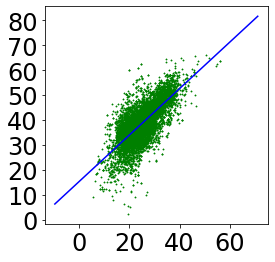

In [38]:
x = data_Ga['Diene_Distort'].to_numpy()
y = data_Ga['deltaGa(Solvent)'].to_numpy()
draw_correlationship_figure(x,y)

0.2465546286040271


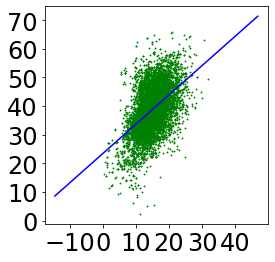

In [39]:
x = data_Ga['Ene_Distort'].to_numpy()
y = data_Ga['deltaGa(Solvent)'].to_numpy()
draw_correlationship_figure(x,y)

0.013873651139103549


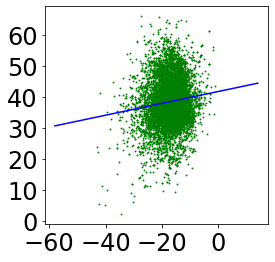

In [40]:
x = -data_Ga['Interaction'].to_numpy()
y = data_Ga['deltaGa(Solvent)'].to_numpy()
draw_correlationship_figure(x,y)

## Heatmap Used in Figure 5

In [105]:
best_2d_fp = [0.868560071, 0.670953629, 0.670352632, 0.83235477]
best_3d_fp = [0.868501891, 0.661610067, 0.685188344, 0.827283178]
best_pretrain = [0.878455927, 0.684620743, 0.666224599, 0.834767596]
physorg = [0.92699665, 0.74409872, 0.73216395, 0.89233082]
svo = [0.93675778, 0.82360676, 0.7863947, 0.92297604]
o =[0.8784559271020388, 0.6846207432743947, 0.6851883440658153, 0.8347675957370564]
result = np.array([best_2d_fp,best_3d_fp,best_pretrain, physorg, svo])
# result = np.array([o, physorg, svo])
result

array([[0.86856007, 0.67095363, 0.67035263, 0.83235477],
       [0.86850189, 0.66161007, 0.68518834, 0.82728318],
       [0.87845593, 0.68462074, 0.6662246 , 0.8347676 ],
       [0.92699665, 0.74409872, 0.73216395, 0.89233082],
       [0.93675778, 0.82360676, 0.7863947 , 0.92297604]])

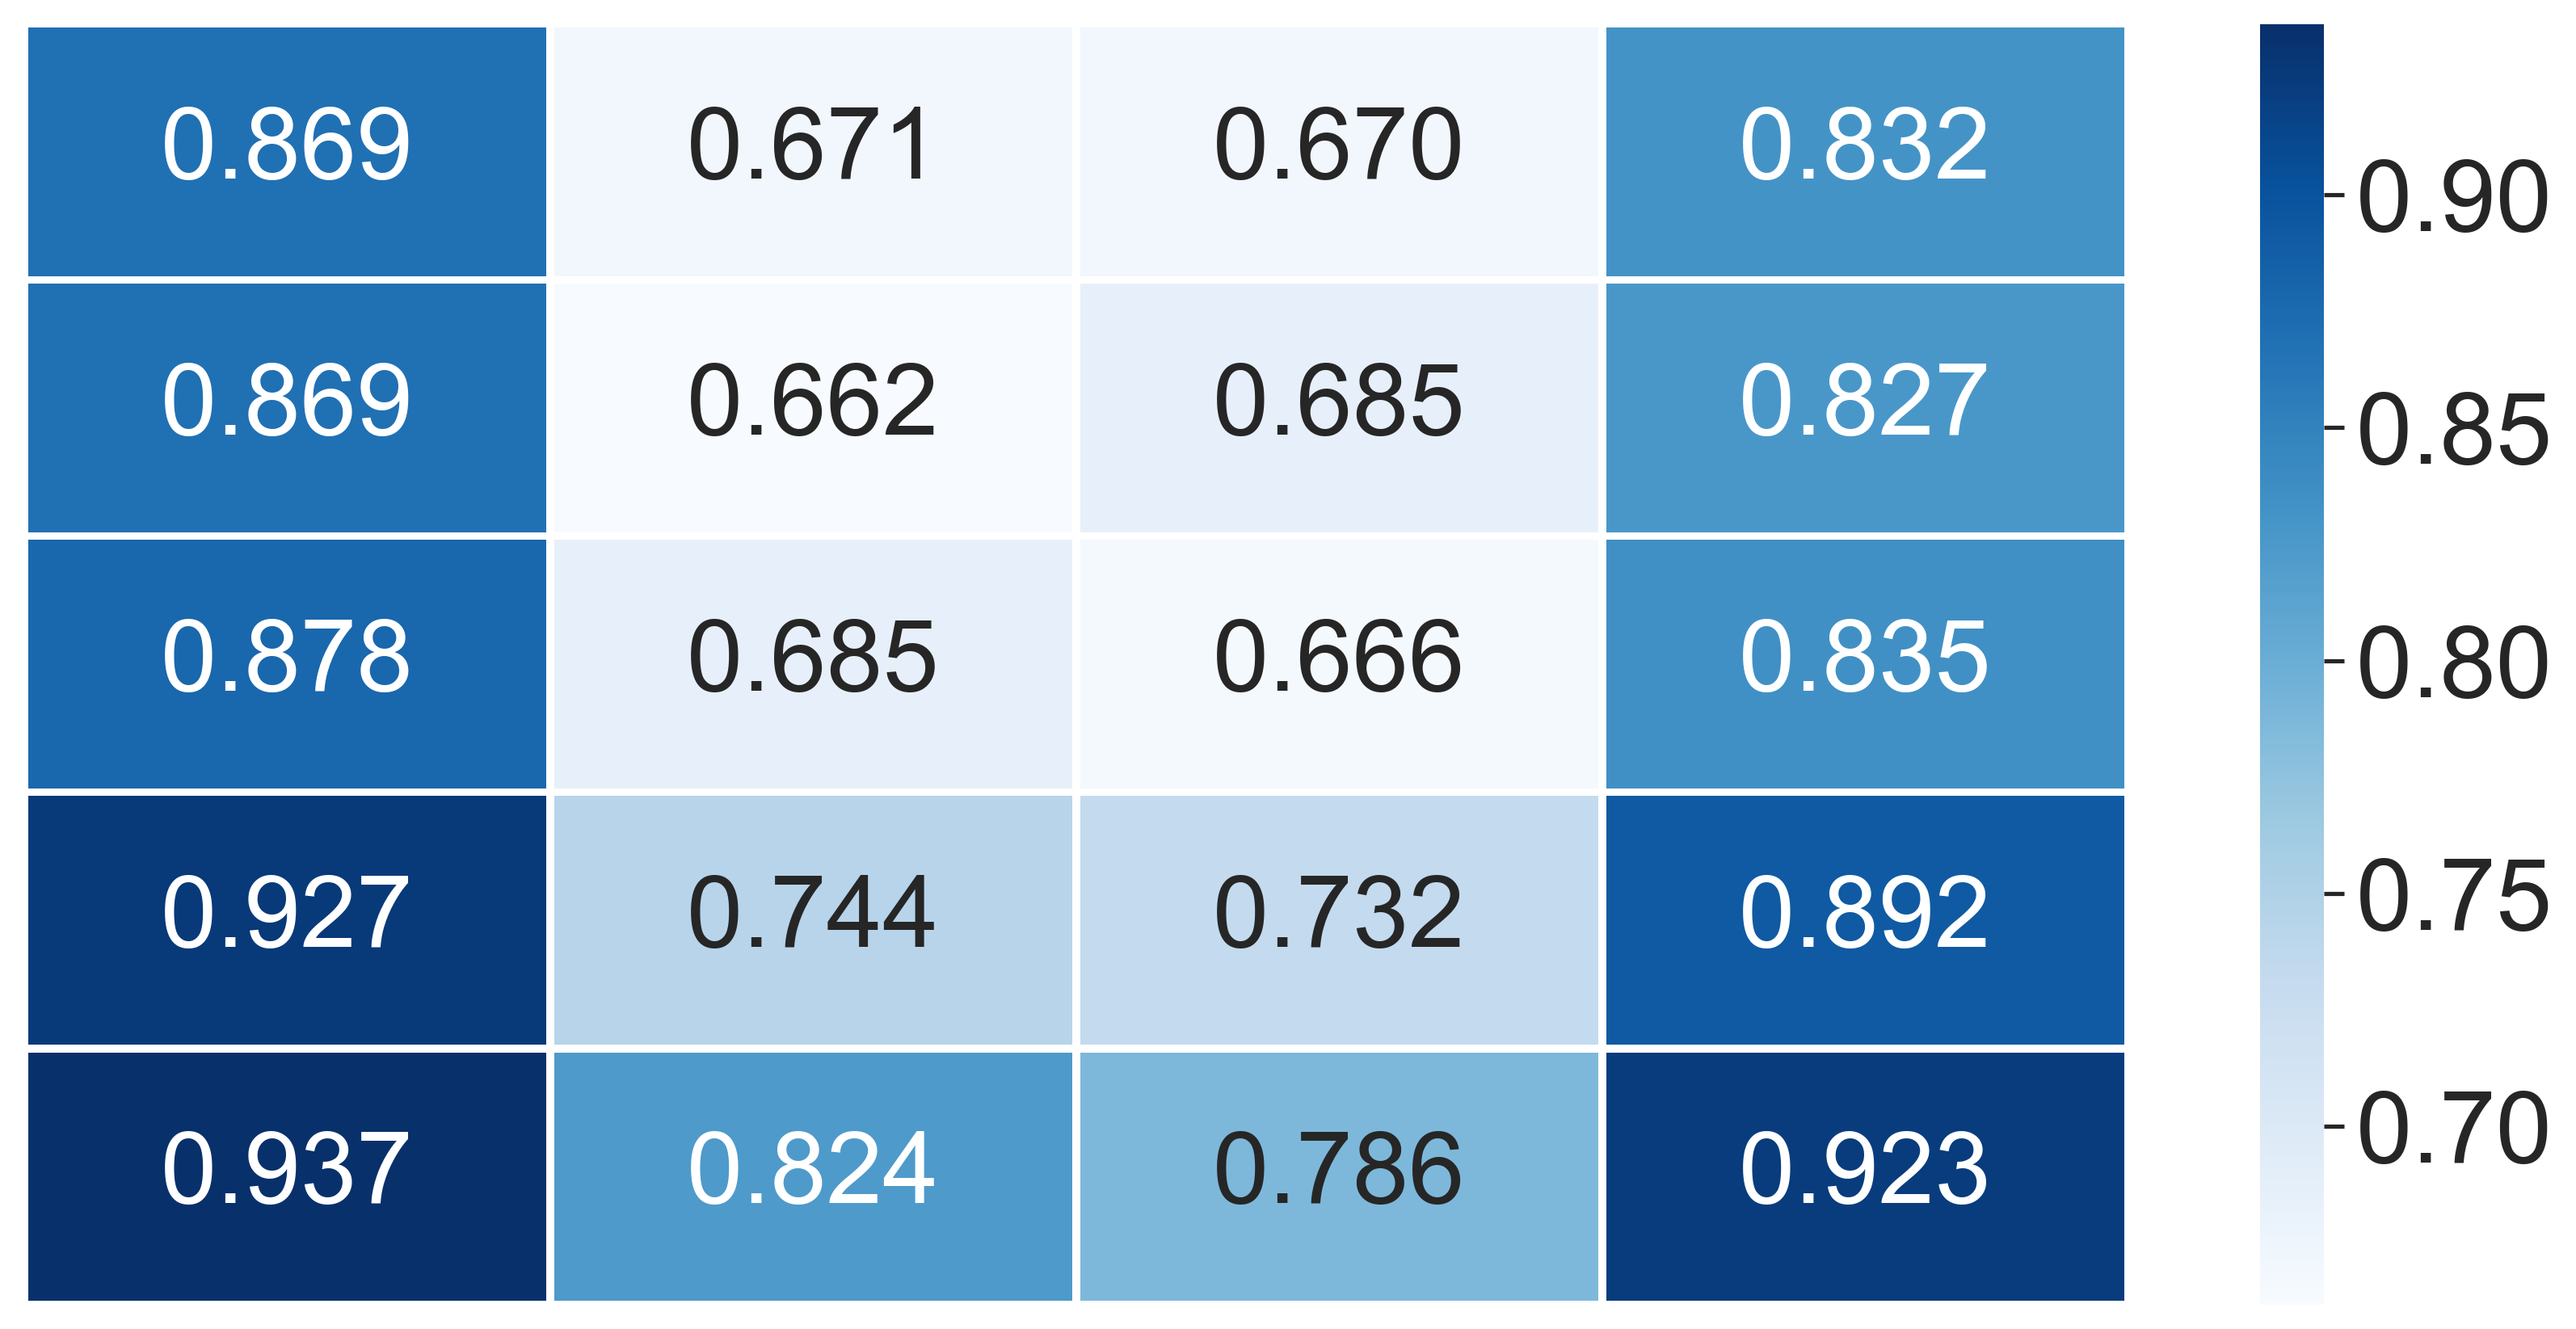

<module 'matplotlib.pyplot' from 'c:\\Users\\Jackie\\anaconda3\\envs\\main\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [106]:
# Y_labels = ["GB", "RF", "ET", "XGB"]
# X_labels = ["DD", "ED", "IN", "E"]
model_train.draw_heatmap(values=result, figure_size=(14, 7))

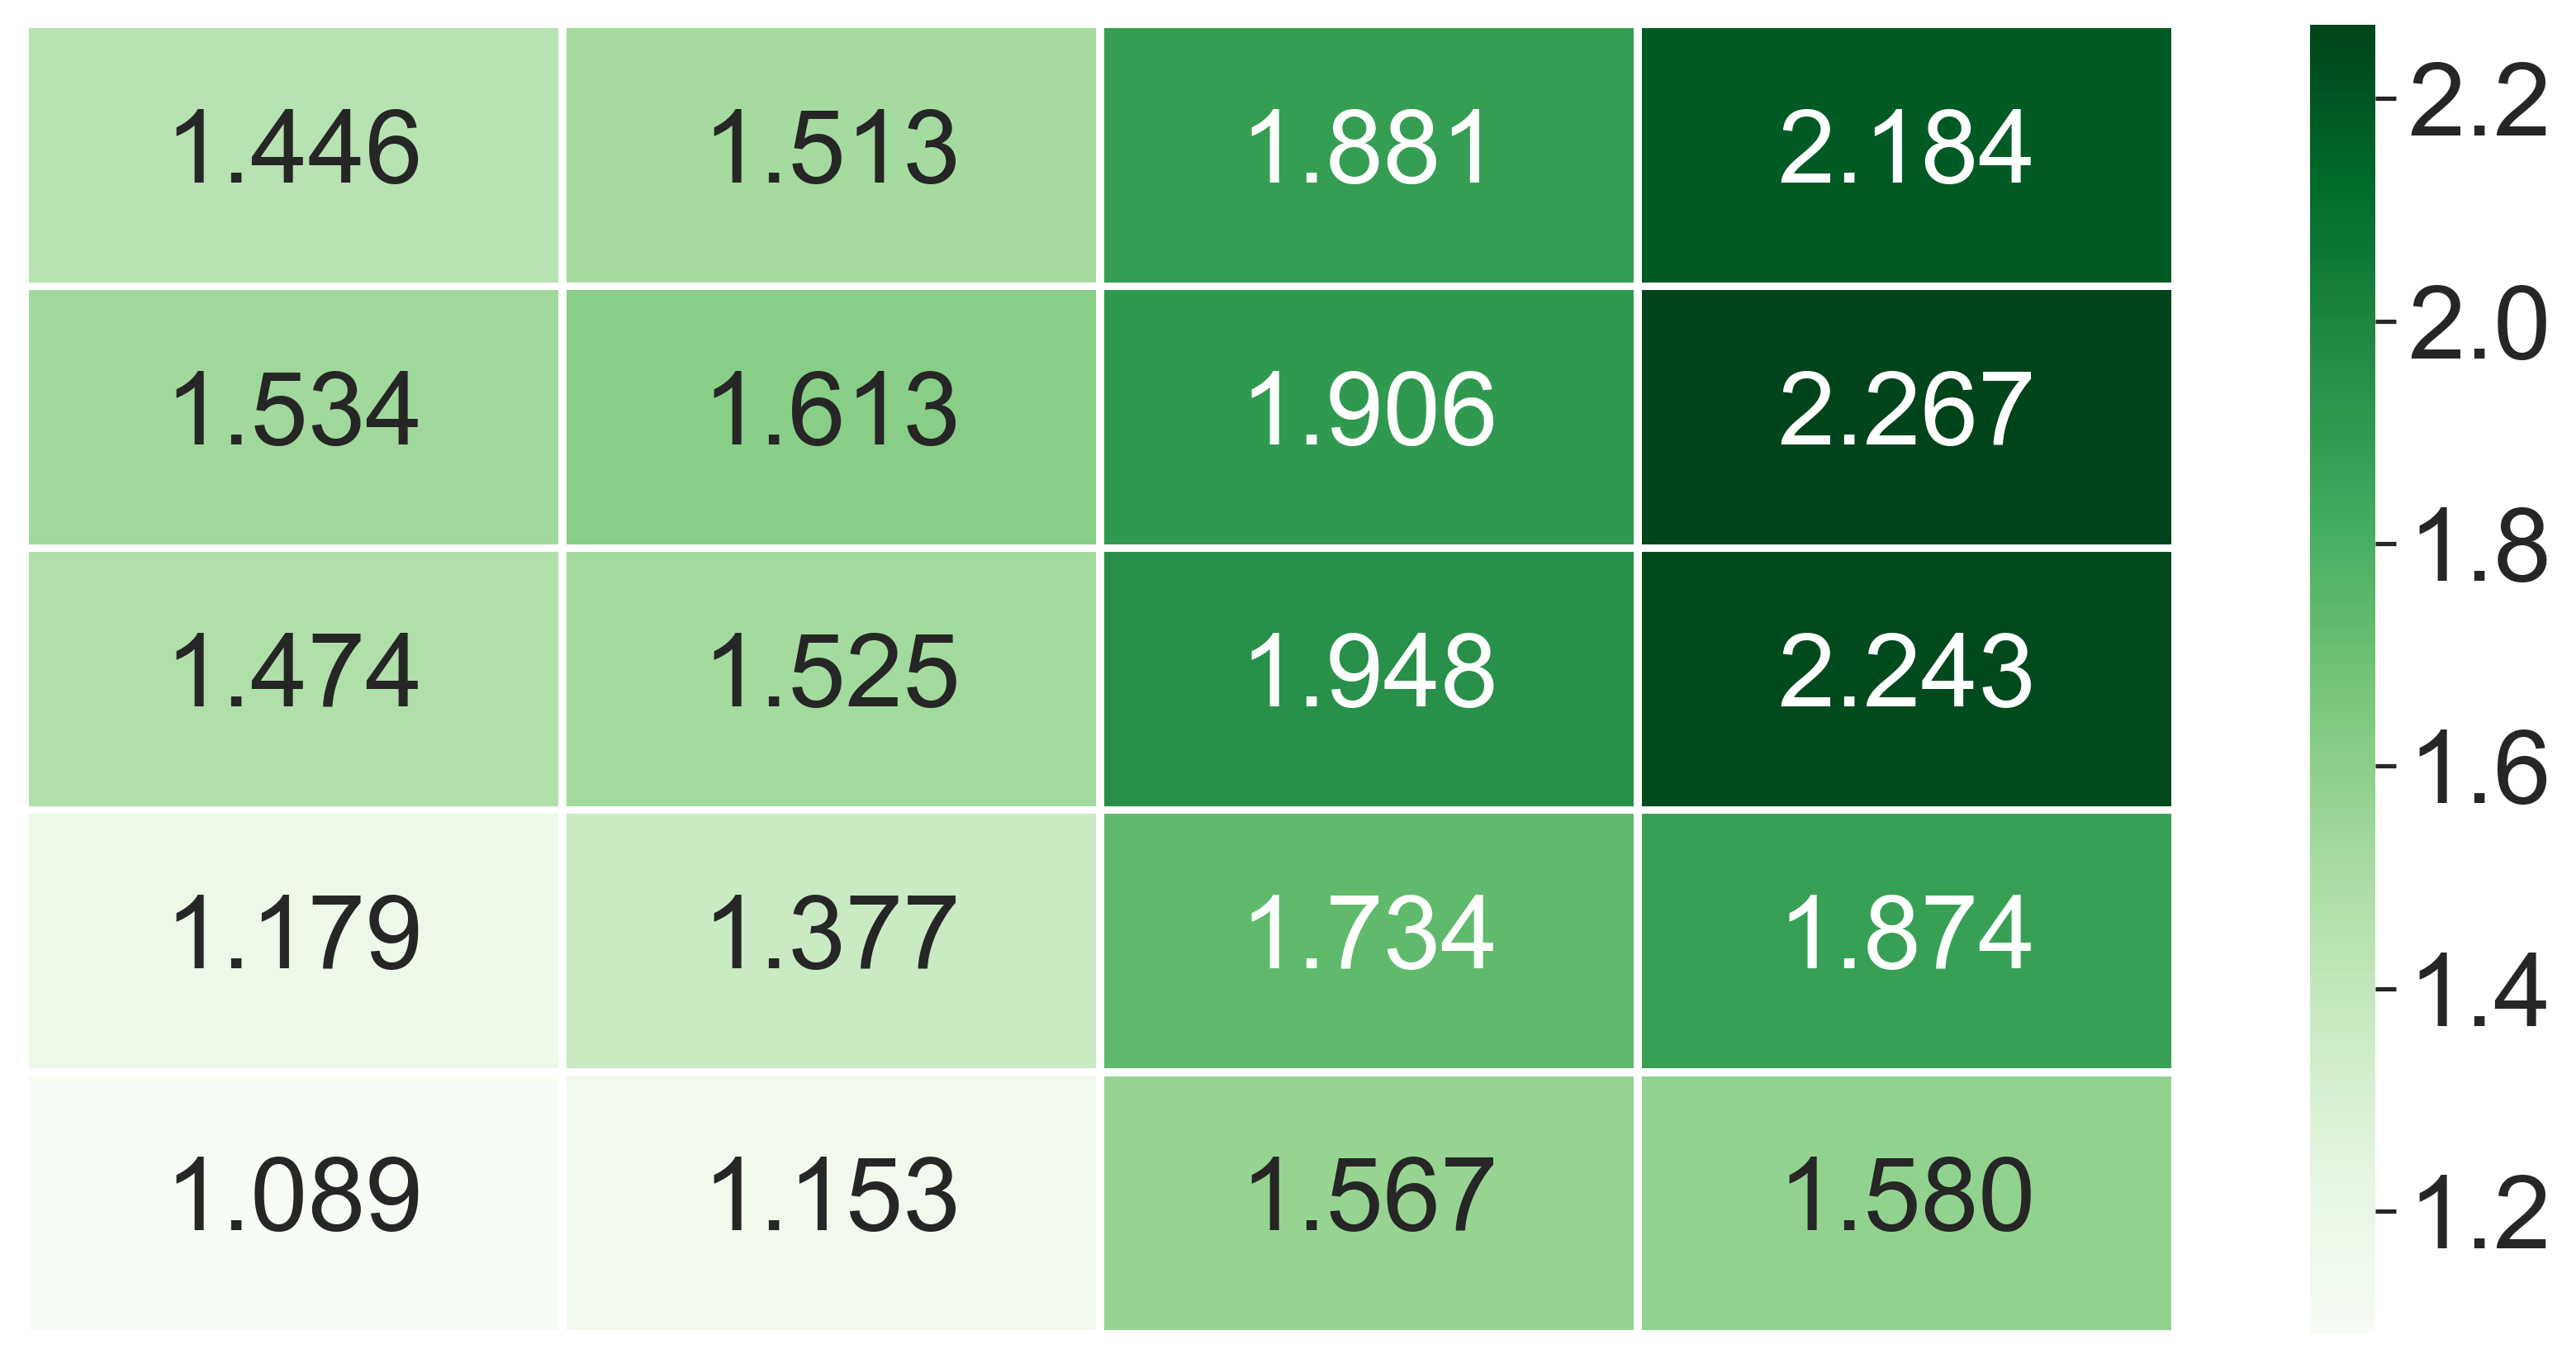

<module 'matplotlib.pyplot' from 'c:\\Users\\Jackie\\anaconda3\\envs\\main\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [103]:
best_2d_fp = [1.44569655, 1.51257416, 1.88100186, 2.18419284]
best_3d_fp = [1.53363857, 1.61313933, 1.9060276, 2.26678806]
best_pretrain = [1.47372336, 1.52471926, 1.9482877, 2.24253289]
physorg = [1.17891877, 1.37743342, 1.73447525, 1.87371062]
svo = [1.08928023, 1.15335966, 1.56740609, 1.5796423]
result = np.array([best_2d_fp,best_3d_fp,best_pretrain, physorg, svo])
model_train.draw_heatmap(values=result, figure_size=(14, 7), colors='Greens')

## Result of all Descriptors and Heatmap Used in SI

In [9]:
dd_result = np.array([[ 0.93675778,  9.05339601e-01, 9.05859294e-01,
         7.21101489e-01, 9.15559009e-01, 9.10429923e-01,
         6.09660871e-01, 6.09712716e-01, 6.09530635e-01,
        -5.04446848e+25, 1.97536888e-01, 7.01091762e-01],
       [ 8.68560071e-01,  8.16153373e-01,  8.07090843e-01,
         4.54688339e-01,  8.25933431e-01,  8.51444725e-01,
         7.69246143e-01,  7.69250543e-01,  7.69470219e-01,
         7.61482739e-01,  7.16465644e-01,  6.21273059e-01],
       [ 8.47144483e-01,  7.80064256e-01,  7.89583394e-01,
         4.03782420e-01,  8.19888995e-01,  7.77876347e-01,
         7.21685737e-01,  7.21689703e-01,  7.21891606e-01,
         7.10923738e-01,  7.36609494e-01,  6.31285446e-01],
       [ 8.49933463e-01,  7.86715794e-01,  7.86587903e-01,
         4.48242631e-01,  8.13851419e-01,  7.80779358e-01,
         7.28323236e-01,  7.28328716e-01,  7.28681215e-01,
         7.20510835e-01,  6.96058268e-01,  6.81126216e-01],
       [ 8.50639138e-01,  7.87064923e-01,  7.54889711e-01,
         4.23983630e-01,  7.89230323e-01,  7.82387153e-01,
         7.31481967e-01,  7.31487698e-01,  7.31856473e-01,
         7.19420733e-01,  6.99137220e-01,  5.95639744e-01],
       [ 8.68501891e-01,  8.10003252e-01,  8.47113795e-01,
         5.36545604e-01,  8.60918697e-01,  8.54146414e-01,
         2.04100597e-01,  4.21293488e-01,  4.19825800e-01,
         3.47998107e-01,  3.58447719e-01,  5.82278245e-01],
       [ 7.62560061e-01,  6.58671974e-01,  5.98648040e-01,
         3.40686761e-01,  6.47920803e-01,  6.53717419e-01,
         6.53204207e-01,  6.53211518e-01,  6.53881189e-01,
         6.39784622e-01,  6.15113837e-01,  6.89204127e-01],
       [ 7.40205523e-01,  6.35679090e-01,  5.62231569e-01,
         3.07325226e-01,  6.17326778e-01,  6.64844723e-01,
         6.50238109e-01,  6.50244193e-01,  6.50745485e-01,
         6.37728945e-01,  6.05100063e-01,  6.72286461e-01],
       [ 8.32682818e-01,  7.52772138e-01,  7.55756663e-01,
         3.75586900e-01,  7.99943047e-01,  7.80320492e-01,
         7.16104109e-01,  7.16111078e-01,  7.16610100e-01,
         7.08025335e-01,  6.53017397e-01,  6.86197702e-01],
       [ 7.95553103e-01,  6.80313875e-01,  6.89311593e-01,
         3.52787617e-01,  7.42709843e-01,  6.80628731e-01,
         6.30480264e-01,  6.30487987e-01,  6.31254494e-01,
         6.19016328e-01,  6.35996957e-01,  6.57628237e-01],
       [ 8.38305864e-01,  7.70614565e-01,  7.89874776e-01,
         4.35275776e-01,  8.12792325e-01,  7.64053551e-01,
         6.90421174e-01,  6.90426643e-01,  6.90812703e-01,
         6.80004021e-01,  6.73297457e-01,  6.25220491e-01],
       [ 8.78455927e-01,  8.16592678e-01,  8.60847262e-01,
         5.62115556e-01,  8.61961229e-01,  8.69852124e-01,
         5.09284691e-01,  5.05314467e-01,  5.07346298e-01,
         4.38770174e-01,  3.39457803e-01,  5.09985636e-01]])
dd_result = np.delete(dd_result, 9, axis=1)
dd_mae = np.array([[1.08928023, 1.39815126e+00, 1.27190838e+00, 2.57467790e+00,
        1.19386031e+00, 1.35891201e+00, 2.91917032e+00, 2.91906366e+00,
        2.91975333e+00, 3.38595591e+13, 4.24099896e+00, 2.37398095e+00],
       [1.44569655e+00, 1.87320433e+00, 1.77087485e+00, 3.71311904e+00,
        1.61264106e+00, 1.59606827e+00, 2.18817491e+00, 2.18814903e+00,
        2.18673551e+00, 2.23163759e+00, 2.14636627e+00, 2.73647248e+00],
       [1.54260421e+00, 1.99923693e+00, 1.81755156e+00, 3.91483297e+00,
        1.63250547e+00, 2.00932567e+00, 2.32739817e+00, 2.32737549e+00,
        2.32627637e+00, 2.38035477e+00, 2.10984732e+00, 2.70588847e+00],
       [1.52623623e+00, 1.98263558e+00, 1.85027045e+00, 3.72707057e+00,
        1.66956867e+00, 2.02683666e+00, 2.34238950e+00, 2.34235034e+00,
        2.33948565e+00, 2.37669961e+00, 2.27548011e+00, 2.48182361e+00],
       [1.57252027e+00, 2.07049702e+00, 2.06676695e+00, 3.83762074e+00,
        1.84201012e+00, 2.08981067e+00, 2.40300190e+00, 2.40297109e+00,
        2.40106968e+00, 2.45806883e+00, 2.23894614e+00, 2.84436144e+00],
       [1.59557723e+00, 2.00930768e+00, 1.68780472e+00, 3.37750744e+00,
        1.53363857e+00, 1.66422791e+00, 4.33452386e+00, 3.58100386e+00,
        3.58361068e+00, 3.80601297e+00, 3.75268974e+00, 2.85327379e+00],
       [2.12974682e+00, 2.70091405e+00, 2.87903254e+00, 4.08978408e+00,
        2.62971909e+00, 2.71520602e+00, 2.70172687e+00, 2.70169852e+00,
        2.69993434e+00, 2.75565781e+00, 2.64314964e+00, 2.46591667e+00],
       [2.25411499e+00, 2.79904524e+00, 3.00230956e+00, 4.21548399e+00,
        2.73026482e+00, 2.65268094e+00, 2.74847779e+00, 2.74844928e+00,
        2.74646625e+00, 2.79750005e+00, 2.74392071e+00, 2.61485017e+00],
       [1.72562354e+00, 2.22261303e+00, 2.10772691e+00, 4.01823568e+00,
        1.82863759e+00, 2.07799105e+00, 2.40713169e+00, 2.40709657e+00,
        2.40497382e+00, 2.44696915e+00, 2.45308509e+00, 2.48657938e+00],
       [1.91481374e+00, 2.55746644e+00, 2.39762067e+00, 4.04642240e+00,
        2.08708013e+00, 2.57575684e+00, 2.77801514e+00, 2.77798342e+00,
        2.77521295e+00, 2.83476877e+00, 2.55338896e+00, 2.61467573e+00],
       [1.60773588e+00, 2.09514401e+00, 1.85721032e+00, 3.77272929e+00,
        1.67841985e+00, 2.13149379e+00, 2.54444755e+00, 2.54440748e+00,
        2.54097254e+00, 2.59164566e+00, 2.36326905e+00, 2.73062049e+00],
       [1.47372336e+00, 1.92179315e+00, 1.57306483e+00, 3.24791924e+00,
        1.51318698e+00, 1.54477762e+00, 3.18261711e+00, 3.20461985e+00,
        3.19810536e+00, 3.43333373e+00, 3.71553828e+00, 3.08047033e+00]])
dd_mae = np.delete(dd_mae, 9, axis=1)

In [19]:
dd_df = pd.DataFrame(g_result, columns=X_labels, index=Y_labels)
dd_df.to_csv("g_result.csv")

In [11]:
X_labels = ["CB", "GB", "RF", "ADB", "ET", "XGB", "Lasso", "Ridge", "BR", "SVR", "KNR"]
Y_labels = ["PhysOrg", "RDKit Desc", "Morgan FP", "RDKit FP", "Modred Desc", "ACSF", "SOAP", "LMBTR", "MBTR", "VAE", "TRFM", "GAE"]
model_train.draw_heatmap(x_labels = X_labels, y_labels = Y_labels, values=g_result, figure_size=(24, 14))

In [13]:
ed_result = np.array([[ 0.82360676,  7.20048026e-01,  6.88753379e-01,
         2.95703738e-01,  6.75905648e-01,  7.14646490e-01,
         4.15008646e-01,  4.15008646e-01,  4.13442090e-01,
        -5.64388455e+25,  9.01397030e-02,  3.12100126e-01],
       [ 6.70953629e-01,  6.38703447e-01,  6.20803414e-01,
         1.65719789e-01,  5.94387926e-01,  6.36727566e-01,
         5.46145231e-01,  5.46153018e-01,  5.47107442e-01,
         5.32082242e-01,  5.82496815e-01,  4.63193002e-01],
       [ 6.49112307e-01,  6.12173129e-01,  6.10412527e-01,
         1.36708090e-01,  6.07702665e-01,  5.73497052e-01,
         5.13341918e-01,  5.13350369e-01,  5.14543859e-01,
         5.03646690e-01,  5.76782678e-01,  4.84885561e-01],
       [ 6.49475285e-01,  6.03547118e-01,  6.13528954e-01,
         1.19827134e-01,  6.07635042e-01,  5.97022938e-01,
         4.68325754e-01,  4.68335087e-01,  4.69875561e-01,
         4.09045172e-01,  5.39070948e-01,  4.28070989e-01],
       [ 6.51536354e-01,  6.19744870e-01,  5.92179703e-01,
         2.14890103e-01,  5.92926161e-01,  6.18227870e-01,
         5.39673075e-01,  5.39683244e-01,  5.41118208e-01,
         5.24955247e-01,  5.60855974e-01,  4.75446462e-01],
       [ 6.41989735e-01,  5.40517904e-01,  5.81669187e-01,
         1.80826839e-01,  6.08276045e-01,  5.53034396e-01,
         1.37934602e-02,  2.33791844e-01,  2.31335574e-01,
         1.72812875e-01,  2.13759250e-01,  3.67163279e-01],
       [ 5.95093130e-01,  4.90802885e-01,  4.38337931e-01,
         1.88829112e-01,  4.84454224e-01,  5.03925510e-01,
         4.59255518e-01,  4.59264878e-01,  4.60839331e-01,
         4.40183029e-01,  4.73099102e-01,  4.41209005e-01],
       [ 5.68977873e-01,  4.61334199e-01,  4.07151918e-01,
         1.64041125e-01,  4.51781491e-01,  4.53968934e-01,
         4.39439468e-01,  4.39449226e-01,  4.41226496e-01,
         4.19397693e-01,  4.65995563e-01,  4.07030978e-01],
       [ 6.61610067e-01,  5.64750507e-01,  5.54337000e-01,
         2.26354299e-01,  6.09714626e-01,  5.95704846e-01,
         4.78981266e-01,  4.78990382e-01,  4.80409005e-01,
         4.60623234e-01,  5.01116705e-01,  4.73007384e-01],
       [ 5.93189229e-01,  4.74665971e-01,  4.76903698e-01,
         1.03530891e-01,  5.37297435e-01,  4.70585804e-01,
         3.92608766e-01,  3.92619436e-01,  3.94925509e-01,
         3.78511966e-01,  4.88848765e-01,  3.90246380e-01],
       [ 6.07769983e-01,  5.42203160e-01,  5.79281464e-01,
         9.18478613e-02,  5.64988051e-01,  5.38301436e-01,
         4.02636904e-01,  4.02645229e-01,  4.04118106e-01,
         3.43607278e-01,  4.85110941e-01,  4.18011084e-01],
       [ 6.84620743e-01,  6.19520694e-01,  6.35140092e-01,
         2.40398815e-01,  6.32473633e-01,  6.24810700e-01,
         3.55032391e-01,  3.54474328e-01,  3.35328790e-01,
         2.81587742e-01,  2.88534389e-01,  4.14869533e-01]])
ed_result = np.delete(ed_result, 9, axis=1)
ed_mae = np.array([[1.15335966, 1.44954746e+00, 1.36233410e+00, 2.32698726e+00,
        1.25944971e+00, 1.25915648e+00, 2.13700838e+00, 2.13700838e+00,
        2.14751770e+00, 4.16420664e+13, 2.79388466e+00, 2.39493641e+00],
       [1.51257416e+00, 1.70095995e+00, 1.67663178e+00, 2.84430721e+00,
        1.65614912e+00, 1.70305709e+00, 1.93485967e+00, 1.93483883e+00,
        1.93228262e+00, 1.96888847e+00, 1.72396972e+00, 2.06179618e+00],
       [1.57935050e+00, 1.77110254e+00, 1.71592027e+00, 2.89483826e+00,
        1.65482186e+00, 1.87762790e+00, 2.00295351e+00, 2.00293176e+00,
        2.00032841e+00, 2.02943538e+00, 1.75868959e+00, 2.04672757e+00],
       [1.57259950e+00, 1.78701928e+00, 1.69043609e+00, 2.93880143e+00,
        1.64287982e+00, 1.80264080e+00, 2.09084449e+00, 2.09082917e+00,
        2.08893629e+00, 2.23130722e+00, 1.83570619e+00, 2.14029044e+00],
       [1.56320961e+00, 1.74162200e+00, 1.74590942e+00, 2.74551927e+00,
        1.69111441e+00, 1.74713316e+00, 1.91866509e+00, 1.91864496e+00,
        1.91650315e+00, 1.95257716e+00, 1.75370249e+00, 2.03696253e+00],
       [1.68838279e+00, 1.96904288e+00, 1.79976700e+00, 2.79400977e+00,
        1.69951078e+00, 1.94095687e+00, 2.95792534e+00, 2.58565112e+00,
        2.59150940e+00, 2.69539775e+00, 2.59939666e+00, 2.30379669e+00],
       [1.78012108e+00, 2.08218642e+00, 2.14200608e+00, 2.76188411e+00,
        2.00329487e+00, 2.01388656e+00, 2.14584852e+00, 2.14583448e+00,
        2.14461191e+00, 2.18481774e+00, 2.01340076e+00, 2.12621434e+00],
       [1.83783437e+00, 2.13863701e+00, 2.20828179e+00, 2.81397962e+00,
        2.06754404e+00, 2.15465638e+00, 2.19765658e+00, 2.19763518e+00,
        2.19346116e+00, 2.23071312e+00, 2.04433484e+00, 2.19077835e+00],
       [1.61313933e+00, 1.90394018e+00, 1.88350792e+00, 2.73406415e+00,
        1.70636851e+00, 1.79160195e+00, 2.10709080e+00, 2.10706610e+00,
        2.10292624e+00, 2.14992148e+00, 1.94439872e+00, 2.07105074e+00],
       [1.77062463e+00, 2.09708899e+00, 2.05815884e+00, 2.90882491e+00,
        1.88286378e+00, 2.10639606e+00, 2.25867695e+00, 2.25866302e+00,
        2.25720750e+00, 2.28788739e+00, 1.94504979e+00, 2.22231819e+00],
       [1.67580010e+00, 1.93124688e+00, 1.77177963e+00, 2.96752740e+00,
        1.73453887e+00, 1.94158899e+00, 2.25744507e+00, 2.25743086e+00,
        2.25564220e+00, 2.37999940e+00, 1.97839917e+00, 2.19812004e+00],
       [1.52471926e+00, 1.77129554e+00, 1.65179952e+00, 2.68477820e+00,
        1.60935944e+00, 1.75430875e+00, 2.32419276e+00, 2.32353236e+00,
        2.36306025e+00, 2.47915647e+00, 2.40730152e+00, 2.15793430e+00]])
ed_mae = np.delete(ed_mae, 9, axis=1)

In [15]:
in_result = np.array([[ 0.7863947,  7.31849202e-01, 7.34261888e-01,  
        3.94937602e-01,  7.49153201e-01,  7.58005461e-01,  
        4.99310247e-01,  4.98696895e-01,  4.97768642e-01,
       -5.83813390e+25,  1.91700620e-01,  4.58155572e-01],
       [ 6.70352632e-01,  6.61215456e-01,  6.28349780e-01,
         3.55550268e-01,  6.11740555e-01,  6.63345852e-01,
         6.17992129e-01,  6.17998211e-01,  6.18531806e-01,
         6.06365497e-01,  5.65713630e-01,  4.75215004e-01],
       [ 6.46644717e-01,  6.18827350e-01,  6.14468112e-01,
         3.06952682e-01,  5.86562904e-01,  6.16864565e-01,
         5.56485704e-01,  5.56492450e-01,  5.57235342e-01,
         5.40498727e-01,  5.47021467e-01,  4.32929458e-01],
       [ 6.50846818e-01,  6.40476247e-01,  6.27897074e-01,
         3.56985705e-01,  6.06771953e-01,  6.32942264e-01,
         5.77907739e-01,  5.77914240e-01,  5.78563659e-01,
         5.67554952e-01,  5.64217833e-01,  5.08105452e-01],
       [ 6.54155085e-01,  6.41023985e-01,  5.95027802e-01,
         3.35937009e-01,  5.80769077e-01,  6.37085437e-01,
         6.15136263e-01,  6.15143789e-01,  6.15912497e-01,
         6.03166586e-01,  5.65644720e-01,  4.54857223e-01],
       [ 6.76138729e-01,  5.83917025e-01,  6.33928466e-01,
         2.49476148e-01,  6.61320593e-01,  6.34581183e-01,
         9.55329632e-02,  2.98073612e-01,  2.95247826e-01,
         2.38374676e-01,  2.65312850e-01,  4.12333413e-01],
       [ 6.16092232e-01,  5.17487917e-01,  4.67358493e-01,
         2.41902984e-01,  5.02874423e-01,  4.88845836e-01,
         4.99716325e-01,  4.99725777e-01,  5.01184944e-01,
         4.86258166e-01,  4.75384320e-01,  4.86834466e-01],
       [ 6.04834620e-01,  5.10139425e-01,  4.38879620e-01,
         2.19519015e-01,  4.74438046e-01,  4.83228817e-01,
         5.12646595e-01,  5.12653443e-01,  5.13472427e-01,
         4.95411640e-01,  4.66997498e-01,  4.80947739e-01],
       [ 6.85188344e-01,  6.12835626e-01,  5.88785969e-01,
         2.68523119e-01,  6.38127564e-01,  6.17805768e-01,
         5.86816981e-01,  5.86825702e-01,  5.87848500e-01,
         5.72752686e-01,  5.22262063e-01,  4.88020356e-01],
       [ 5.98087487e-01,  4.93088819e-01,  4.97463038e-01,
         2.11776511e-01,  5.46046270e-01,  4.90227714e-01,
         4.22384346e-01,  4.22394011e-01,  4.24211289e-01,
         3.71610003e-01,  4.55593611e-01,  3.74369940e-01],
       [ 6.23187495e-01,  5.90630991e-01,  5.93852674e-01,
         2.52473539e-01,  5.90918587e-01,  5.84371765e-01,
         4.97640126e-01,  4.97648454e-01,  4.98820765e-01,
         4.81742383e-01,  5.00937985e-01,  4.28829874e-01],
       [ 6.66224599e-01,  6.09156796e-01,  6.24653189e-01,
         3.02084921e-01,  6.35049313e-01,  6.08335150e-01,
         3.61238904e-01,  3.59976078e-01,  3.56528145e-01,
         3.14973612e-01,  2.95509184e-01,  4.01195021e-01]])
in_result = np.delete(in_result, 9, axis=1)
in_mae = np.array([[1.5796423, 2.16606086e+00, 1.96719492e+00,
        3.75156911e+00, 1.84305449e+00, 1.86836901e+00, 4.00870203e+00,
        4.00870203e+00, 4.01289675e+00, 3.07086067e+13, 5.37754502e+00, 3.39710939e+00],
       [1.88100186e+00, 2.03708575e+00, 2.04543720e+00, 3.11934506e+00,
        2.02536118e+00, 2.03288490e+00, 2.21669150e+00, 2.21666542e+00,
        2.21377647e+00, 2.24755374e+00, 2.17396175e+00, 2.52400900e+00],
       [1.95858967e+00, 2.17242620e+00, 2.09921775e+00, 3.27107537e+00,
        2.09109963e+00, 2.18143301e+00, 2.40215808e+00, 2.40211653e+00,
        2.39562377e+00, 2.45578013e+00, 2.23975398e+00, 2.61457862e+00],
       [1.93101561e+00, 2.10137739e+00, 2.03703049e+00, 3.13250195e+00,
        2.03184470e+00, 2.13338924e+00, 2.33865957e+00, 2.33862974e+00,
        2.33498509e+00, 2.36964245e+00, 2.19612509e+00, 2.40281486e+00],
       [1.93736210e+00, 2.10437774e+00, 2.16195221e+00, 3.17939835e+00,
        2.12326180e+00, 2.12860051e+00, 2.22782316e+00, 2.22778134e+00,
        2.22239674e+00, 2.26106966e+00, 2.18951720e+00, 2.57012032e+00],
       [1.97544163e+00, 2.31622771e+00, 2.06790955e+00, 3.35901712e+00,
        1.93525941e+00, 2.12517563e+00, 3.49144775e+00, 3.05151878e+00,
        3.06032166e+00, 3.23711488e+00, 3.05648223e+00, 2.70919111e+00],
       [2.12421777e+00, 2.48893344e+00, 2.56211619e+00, 3.35862831e+00,
        2.41379878e+00, 2.58133789e+00, 2.55009188e+00, 2.55005393e+00,
        2.54329337e+00, 2.57816785e+00, 2.43807493e+00, 2.45903390e+00],
       [2.17019745e+00, 2.51166275e+00, 2.64341958e+00, 3.41786166e+00,
        2.48182679e+00, 2.60326249e+00, 2.54475772e+00, 2.54472207e+00,
        2.53844403e+00, 2.59647066e+00, 2.49945438e+00, 2.46583306e+00],
       [1.90602760e+00, 2.19767240e+00, 2.20383663e+00, 3.35057562e+00,
        2.00520588e+00, 2.18867105e+00, 2.33473419e+00, 2.33469099e+00,
        2.32840293e+00, 2.37020811e+00, 2.32377581e+00, 2.49390970e+00],
       [2.17928803e+00, 2.55691955e+00, 2.47173880e+00, 3.42117753e+00,
        2.29048434e+00, 2.56376360e+00, 2.75241508e+00, 2.75239128e+00,
        2.74784805e+00, 2.89020520e+00, 2.51028048e+00, 2.76745090e+00],
       [2.03331391e+00, 2.24622558e+00, 2.15075927e+00, 3.38579439e+00,
        2.11450750e+00, 2.27520337e+00, 2.55085469e+00, 2.55082845e+00,
        2.54662914e+00, 2.59379754e+00, 2.37890258e+00, 2.67260746e+00],
       [1.94828770e+00, 2.22378620e+00, 2.07313707e+00, 3.22344587e+00,
        2.02140923e+00, 2.21762907e+00, 2.88991766e+00, 2.88972929e+00,
        2.89699197e+00, 2.96709863e+00, 2.94746833e+00, 2.75391391e+00]])
in_mae = np.delete(in_mae, 9, axis=1)

In [16]:
g_result = np.array([[ 0.92297604, 8.65428753e-01, 8.73090526e-01,
         6.43108854e-01,  8.84044022e-01,  8.95358523e-01,
         5.58687340e-01,  5.58687340e-01,  5.57608058e-01,
        -1.86985752e+25,  2.10905304e-01,  6.64584897e-01],
       [ 8.32354770e-01,  7.81764616e-01,  7.66744001e-01,
         4.77849888e-01,  7.99116414e-01,  7.74780395e-01,
         6.97282103e-01,  6.97288324e-01,  6.97752230e-01,
         6.89411312e-01,  6.45018898e-01,  6.03810882e-01],
       [ 8.13835789e-01,  7.39209656e-01,  7.63770288e-01,
         4.14749440e-01,  7.86506363e-01,  7.36290148e-01,
         6.61664767e-01,  6.61670143e-01,  6.62073639e-01,
         6.54988039e-01,  6.41455711e-01,  6.22892226e-01],
       [ 8.23645447e-01,  7.61749917e-01,  7.79139648e-01,
         4.07196223e-01,  7.98583031e-01,  7.87162444e-01,
         6.63857666e-01,  6.63864136e-01,  6.64402517e-01,
         6.57024585e-01,  6.22006329e-01,  6.48271642e-01],
       [ 8.16348272e-01,  7.53409338e-01,  7.38708978e-01,
         4.20315832e-01,  7.64170158e-01,  7.45275471e-01,
         6.79387335e-01,  6.79394688e-01,  6.80023095e-01,
         6.69999424e-01,  6.30490355e-01,  5.56209022e-01],
       [ 8.27283178e-01,  7.55495990e-01,  7.99420681e-01,
         4.75288960e-01,  8.18569637e-01,  8.04045708e-01,
         2.17531299e-01,  3.74869597e-01,  3.73956950e-01,
         2.58688867e-01,  3.15541480e-01,  5.57002100e-01],
       [ 7.32674430e-01,  6.22544088e-01,  5.82869663e-01,
         3.48521255e-01,  6.33639630e-01,  6.62705363e-01,
         5.82619353e-01,  5.82627296e-01,  5.83535035e-01,
         5.66224332e-01,  5.39231828e-01,  6.66116050e-01],
       [ 7.21342077e-01,  6.16500422e-01,  5.65606048e-01,
         3.44837669e-01,  6.09635836e-01,  6.47674421e-01,
         5.91077168e-01,  5.91083525e-01,  5.91711226e-01,
         5.80639023e-01,  5.23606486e-01,  6.47586804e-01],
       [ 8.15498212e-01,  7.32341345e-01,  7.42612097e-01,
         4.60666720e-01,  7.90081297e-01,  7.63203590e-01,
         6.76136735e-01,  6.76143346e-01,  6.76673432e-01,
         6.66504958e-01,  6.09339918e-01,  6.94401325e-01],
       [ 7.62019665e-01,  6.34807783e-01,  6.61438628e-01,
         3.39303016e-01,  7.14290413e-01,  6.93671669e-01,
         5.55484229e-01,  5.55492170e-01,  5.56469668e-01,
         5.41185631e-01,  5.30971952e-01,  6.23517688e-01],
       [ 8.04688357e-01,  7.34158270e-01,  7.57632618e-01,
         4.27613881e-01,  7.78014635e-01,  7.24043284e-01,
         6.18953768e-01,  6.18960187e-01,  6.19567967e-01,
         6.08418023e-01,  5.88741621e-01,  6.22078991e-01],
       [ 8.34767596e-01,  7.55220667e-01,  8.05046090e-01,
         5.07333707e-01,  8.20107559e-01,  7.67635470e-01,
         4.41613372e-01,  4.45252940e-01,  4.38206741e-01,
         3.59954282e-01,  2.73094757e-01,  4.99979202e-01]])
g_result = np.delete(g_result, 9, axis=1)
g_mae = np.array([[1.87371062e+00, 2.24463670e+00, 2.15619452e+00, 3.81329419e+00,
        2.10677367e+00, 1.97688786e+00, 4.24076243e+00, 4.24076243e+00,
        4.24710475e+00, 2.79317082e+13, 5.37786102e+00, 3.40299263e+00],
       [2.18419284e+00, 2.66314779e+00, 2.61524233e+00, 4.58697166e+00,
        2.35241370e+00, 2.70107798e+00, 3.24411454e+00, 3.24405834e+00,
        3.23928060e+00, 3.28644910e+00, 3.22354302e+00, 3.64935484e+00],
       [2.31198224e+00, 2.88371366e+00, 2.60774048e+00, 4.88859713e+00,
        2.43876846e+00, 2.90281331e+00, 3.33804042e+00, 3.33798659e+00,
        3.33252874e+00, 3.38789398e+00, 3.27400869e+00, 3.50796503e+00],
       [2.25047078e+00, 2.78281247e+00, 2.52122637e+00, 4.93061810e+00,
        2.35179101e+00, 2.60073515e+00, 3.37105280e+00, 3.37097664e+00,
        3.36324747e+00, 3.41475550e+00, 3.36926584e+00, 3.43288560e+00],
       [2.32508909e+00, 2.88093669e+00, 2.82368432e+00, 4.84911476e+00,
        2.59157664e+00, 2.93284832e+00, 3.32912989e+00, 3.32908914e+00,
        3.32531675e+00, 3.37626012e+00, 3.30757406e+00, 3.83251656e+00],
       [2.37769501e+00, 2.92580836e+00, 2.49432928e+00, 4.49887150e+00,
        2.26678806e+00, 2.57821835e+00, 5.36808635e+00, 4.75599519e+00,
        4.75926666e+00, 5.24804947e+00, 4.90448504e+00, 3.82227335e+00],
       [2.90985068e+00, 3.62694515e+00, 3.73496188e+00, 5.08528282e+00,
        3.41307401e+00, 3.33513560e+00, 3.81452934e+00, 3.81451031e+00,
        3.81365182e+00, 3.90644291e+00, 3.78726068e+00, 3.26909987e+00],
       [2.99246591e+00, 3.69059217e+00, 3.84555426e+00, 5.12053852e+00,
        3.54665653e+00, 3.42665315e+00, 3.80898630e+00, 3.80894907e+00,
        3.80511838e+00, 3.86061548e+00, 3.91961834e+00, 3.44367890e+00],
       [2.37119352e+00, 3.00371153e+00, 2.81056151e+00, 4.63595489e+00,
        2.46516417e+00, 2.81685269e+00, 3.37111664e+00, 3.37107280e+00,
        3.36711691e+00, 3.42291238e+00, 3.44953440e+00, 3.16372955e+00],
       [2.72114181e+00, 3.54257576e+00, 3.24495512e+00, 5.13866518e+00,
        2.90568492e+00, 3.18930738e+00, 3.96139728e+00, 3.96132483e+00,
        3.95031688e+00, 4.02596015e+00, 3.82296897e+00, 3.54496896e+00],
       [2.39013771e+00, 2.97848521e+00, 2.66247377e+00, 4.81346227e+00,
        2.48471193e+00, 3.01649404e+00, 3.63052169e+00, 3.63045188e+00,
        3.62095810e+00, 3.68312851e+00, 3.55378462e+00, 3.56106776e+00],
       [2.24253289e+00, 2.86342688e+00, 2.42377518e+00, 4.33537045e+00,
        2.31544465e+00, 2.77914134e+00, 4.35786576e+00, 4.35008881e+00,
        4.36804119e+00, 4.64561351e+00, 4.96770232e+00, 4.00710671e+00]])
g_mae = np.delete(g_mae, 9, axis=1)